# Laos TOKYO Paleomag Data Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
from scipy.stats import linregress
from scipy.optimize import curve_fit

# Site Tests and Plans

Paleomag Tests:
Thermal Profiles - rind to core
    did laterite form before or after?
        likely secondarty as super heating would remove rind. heating could also weaken rind and allow for easier weathering
        laterite directions vs basalt directions
        
    Microscopy to look for fused grains
    
Paleointensity
Poalrity
Rock Mag the works
shock induced magnetism
Regional conglomerate tests on ejecta boulders

Paleomag sites:
    Thermal Profiles:

    Conglomerate Tests:


Geochem Tests:
    Dating
    Minerology
    

Geochron sites:
    Trash Quarry

Microscopy:
    thin sections to look for fused grains

In [10]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
sample_data = pd.read_excel("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Laos Paleomag Sample Notes.xlsx")
sample_data

,Sun Compass Orientation Spreadsheet?,Prepared and Labelled?,Rename,Site,Samples,block or core,strike,dip,sun,date,time,core strike,core dip,photo,note 1,note 2,test 1,test 2,test 3,test 4,potential age
0,NaN,NaN,NaN,PKQ24-A-P,3A,core,292.0,49,NaN,2024-03-12,10:45:00,NaN,NaN,NaN,NaN,NaN,conglomerate,thermal,intensity,NaN,NaN
1,NaN,NaN,NaN,PKQ24-A-P,3B,core,307.0,42,359.0,2024-03-12,10:48:00,NaN,NaN,NaN,NaN,NaN,conglomerate,thermal,intensity,NaN,NaN
2,NaN,NaN,NaN,PKQ24-A-P,4A,core,278.0,49,316.0,2024-03-12,11:14:00,NaN,NaN,NaN,NaN,NaN,conglomerate,thermal,intensity,NaN,NaN
3,NaN,NaN,NaN,PKQ24-A-P,4B,core,283.0,54,311.0,2024-03-12,11:25:00,NaN,NaN,NaN,NaN,NaN,conglomerate,thermal,intensity,NaN,NaN
4,NaN,NaN,NaN,PKQ24-A-P,1A,core,NaN,NaN,NaN,2024-03-12,NaN,NaN,NaN,NaN,NaN,NaN,conglomerate,thermal,intensity,NaN,NaN
5,NaN,NaN,NaN,PKQ24-A-P,2A,core,340.0,72,340.0,2024-03-12,12:03:00,NaN,NaN,NaN,laterite top,NaN,conglomerate,thermal,intensity,NaN,NaN
6,NaN,NaN,NaN,PKQ24-A-P,2B,core,305.0,72,301.0,2024-03-12,12:11:00,NaN,NaN,NaN,NaN,NaN,conglomerate,thermal,intensity,NaN,NaN
7,NaN,NaN,NaN,PKQ24-A-P,5A,core,359.0,57,333.0,2024-03-12,12:36:00,NaN,NaN,NaN,laterite top,NaN,conglomerate,thermal,intensity,NaN,NaN
8,NaN,NaN,NaN,PKQ24-A-P,5B,core,350.0,50,314.0,2024-03-12,12:38:00,NaN,NaN,NaN,NaN,NaN,conglomerate,thermal,intensity,NaN,NaN
9,NaN,NaN,NaN,PKQ24-A-P,5C,core,349.0,56.5,316.0,2024-03-12,12:39:00,NaN,NaN,NaN,laterite top,NaN,conglomerate,thermal,intensity,NaN,NaN


# VSM Data - All

In [27]:
VSM_data = pd.read_xls("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/TekTites_VSM_Data.csv")
VSM_data.head()

,marker_size,color,symbol,Group,Group 2,Weathered t/b,Laterite,Sample #,Mass (g),Hcr/Hc,Mr/Ms,Hc(mT),Mr(µAm^2),Ms(µAm^2),Unnamed: 14,Hcr(mT),Mr(µAm^2).1,Date Measured,Forc?,Comments
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control hldr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,blank holder with drop of glue; generally 100 ...
1,NaN,NaN,NaN,NB: save the numbers after 70% standard parama...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,300.0,red,o,PO Farm Exsitu tektite,Tektite (exsitu),NaN,NaN,PO-T1,1.090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25-Mar,NaN,Paramagnertic!!! Correction goes really FLAT!
3,300.0,orange,o,PO Farm Exsitu tektite,Tektite (exsitu),NaN,NaN,PO-T2,0.446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25-Mar,NaN,Paramagnertic!!! Correction goes really FLAT!
4,300.0,salmon,x,PO Farm Exsitu Concretion,Concretion (exsitu),NaN,NaN,PO-Con. 1,0.218,2.945994,0.39632,168.5,2.24,5.652,NaN,496.4,2.24,25-Mar,NaN,red ball about 5 mm


In [28]:
VSM_data.dropna(subset=['Hcr/Hc', 'Mr/Ms'], inplace=True)
VSM_data.head()

,marker_size,color,symbol,Group,Group 2,Weathered t/b,Laterite,Sample #,Mass (g),Hcr/Hc,Mr/Ms,Hc(mT),Mr(µAm^2),Ms(µAm^2),Unnamed: 14,Hcr(mT),Mr(µAm^2).1,Date Measured,Forc?,Comments
4,300.0,salmon,x,PO Farm Exsitu Concretion,Concretion (exsitu),NaN,NaN,PO-Con. 1,0.218,2.945994,0.396320,168.50,2.240,5.652,NaN,496.40,2.240,25-Mar,NaN,red ball about 5 mm
5,300.0,green,x,PO Farm Exsitu Concretion,Concretion (exsitu),NaN,NaN,PO-Con. 2,0.180,2.015451,0.512558,278.30,2.306,4.499,NaN,560.90,1.772,25-Mar,NaN,red ball about 4 mm
6,300.0,blue,x,PO Farm Exsitu Concretion,Concretion (exsitu),NaN,NaN,PO-Con. 3,2.270,1.297584,0.672204,302.10,24.280,36.120,NaN,392.00,22.450,25-Mar,NaN,smooth smooth survace concretion fairly large
7,300.0,fuchsia,x,PO Farm Exsitu Concretion,Concretion (exsitu),NaN,NaN,PO-Con. 4,1.030,1.337488,0.695577,312.90,9.592,13.790,NaN,418.50,8.983,25-Mar,NaN,dull surface
10,300.0,red,^,Volcanics,Diamicton Basalt Boulder,bottom,no,NWF24-C-P8,0.307,1.816501,0.327133,21.09,25.500,77.950,NaN,38.31,25.190,28-Mar,NaN,"This is a chip frpm inside this concretion, ~4..."


### Day Diagrams Mr/Ms vs Hcr/Hc - Rock Type

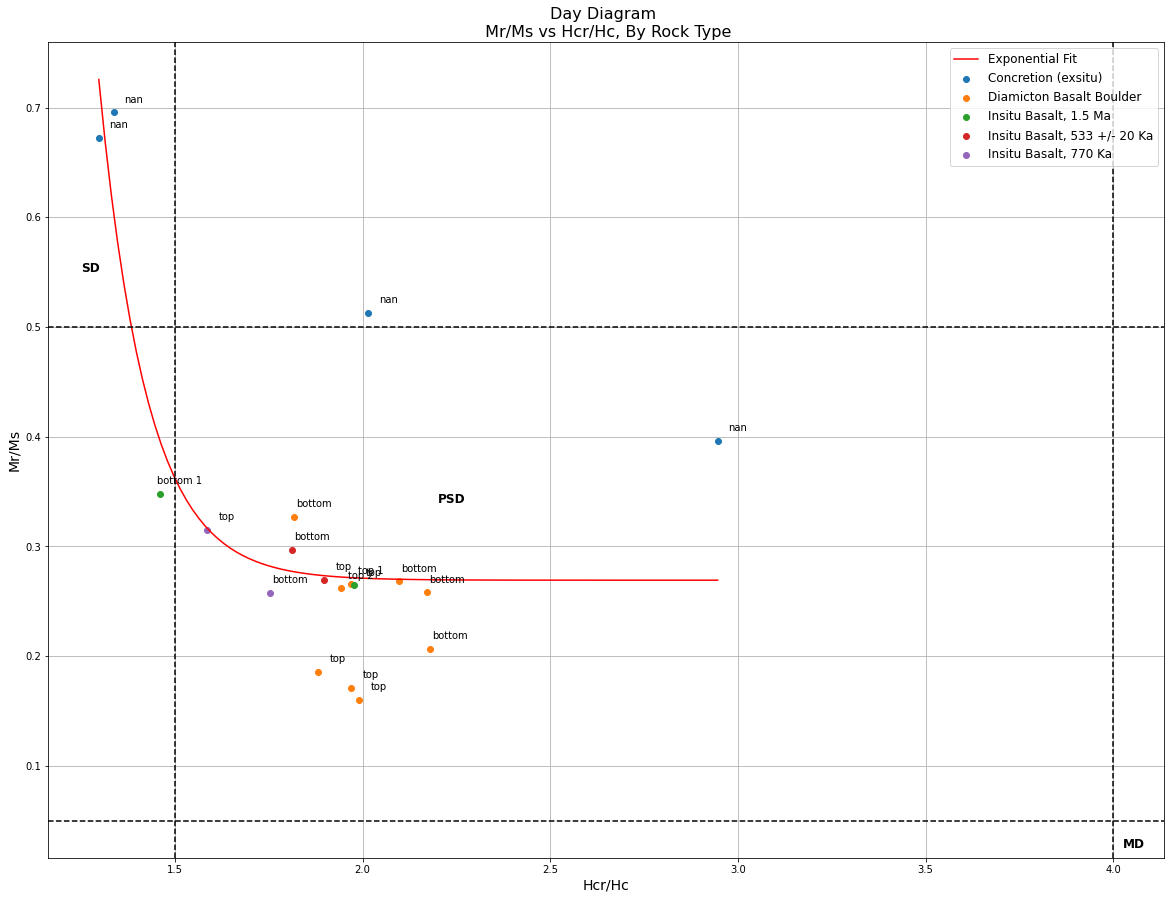

In [29]:
# Calculate the ratios
#VSM_data['Mr/Ms'] = VSM_data['Mr(µAm^2)'] / VSM_data['Ms(µAm^2)']
#VSM_data['Hcr/Hc'] = VSM_data['Hcr(mT)'] / VSM_data['Hc(mT)']

# Create scatter plot
plt.figure(figsize=(20, 15))
#plt.scatter(VSM_data['Hcr/Hc'], VSM_data['Mr/Ms'], color='blue', alpha=0.5)

# Iterate over unique groups and plot their data separately
for group, data in VSM_data.groupby('Group 2'):
    plt.scatter(data['Hcr/Hc'], data['Mr/Ms'], label=group)

for index, row in VSM_data.iterrows():
    plt.annotate(row['Weathered t/b'], (row['Hcr/Hc'], row['Mr/Ms']), textcoords="offset points", xytext=(20,10), ha='center')

# Define an exponential function
def exponential_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# Perform curve fitting
popt, pcov = curve_fit(exponential_func, VSM_data['Hcr/Hc'], VSM_data['Mr/Ms'])

# Generate y-values for the fitted curve
x_values = np.linspace(min(VSM_data['Hcr/Hc']), max(VSM_data['Hcr/Hc']), 100)
y_values = exponential_func(x_values, *popt)

# Plot the fitted curve
plt.plot(x_values, y_values, linestyle='-', color='red', label='Exponential Fit')

# Add domain vertical lines
plt.axvline(x=1.5, color='black', linestyle='--', label='')
plt.axvline(x=4, color='black', linestyle='--', label='')

# Add domain horizontal lines
plt.axhline(y=0.05, color='black', linestyle='--', label='')
plt.axhline(y=0.5, color='black', linestyle='--', label='')

# Add text label
plt.text(1.25, 0.55, 'SD', fontsize=12, fontweight=1000)
plt.text(2.2, 0.34, 'PSD', fontsize=12, fontweight=1000)
plt.text(4.025, 0.025, 'MD', fontsize=12, fontweight=1000)

# Set labels and title
plt.xlabel('Hcr/Hc', fontsize=14)
plt.ylabel('Mr/Ms', fontsize=14)
plt.title('Day Diagram \n Mr/Ms vs Hcr/Hc, By Rock Type',fontsize=16, fontweight=500)

# Show plot
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/day_diagram_rock_type.png")
plt.show()


### Day Diagrams Mr/Ms vs Hcr/Hc - Sample Number

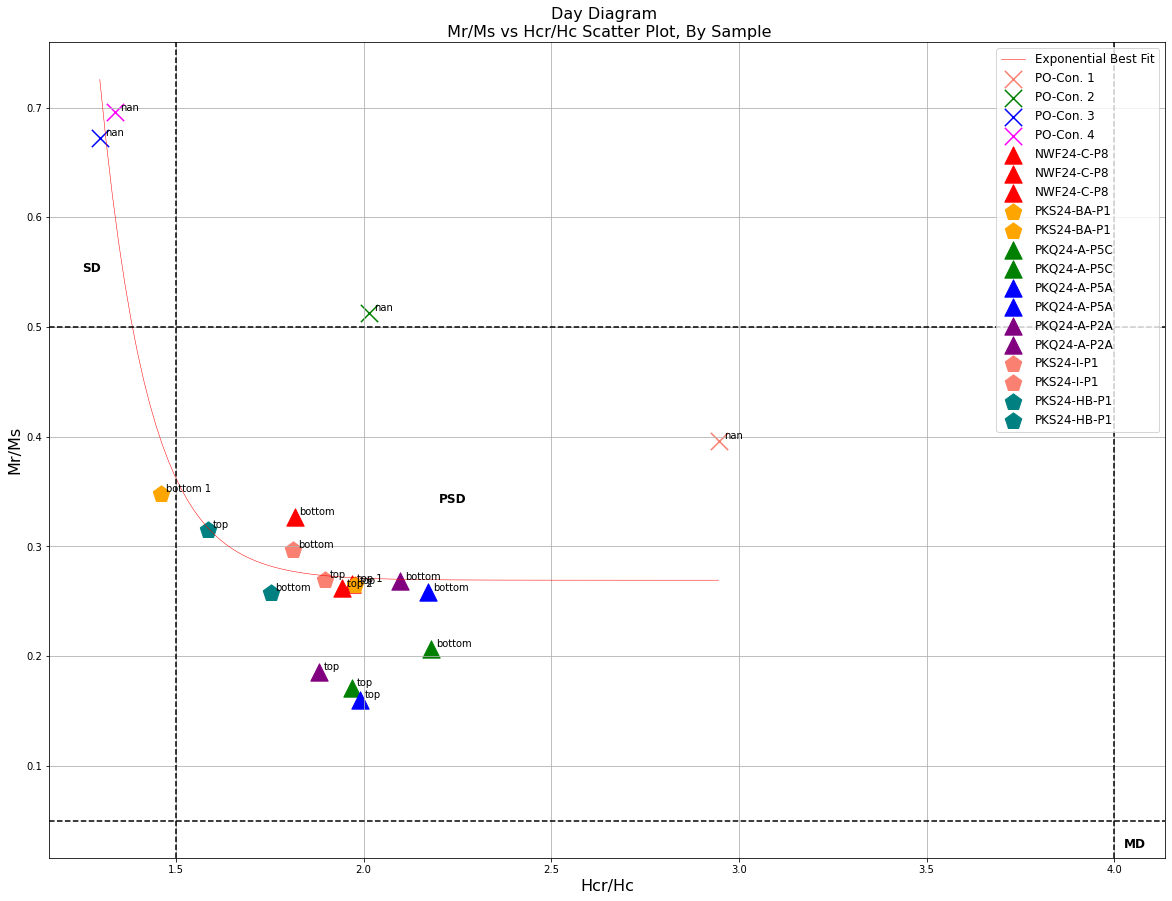

In [30]:
# Create scatter plot
plt.figure(figsize=(20, 15))

# Iterate over unique sample numbers and plot their data separately
#markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'x', '+', '1', '2', '3', '4', '8', 'H', 'h']  
#colors = ['blue', 'green', 'red', 'orange', 'purple', 'cyan', 'magenta', 'salmon', 
#          'brown', 'mediumvioletred', 'teal', 'lavender', 'lightgreen', 'lightblue', 'lime', 'darkred']


#for i, (sample, data) in enumerate(VSM_data.groupby('Sample #')):
 #   plt.scatter(data['Hcr/Hc'], data['Mr/Ms'], label=sample, marker=markers[i % len(markers)], color=colors[i % len(colors)])

#for i, (sample, data) in enumerate(VSM_data.groupby('Sample #')):
    #plt.scatter(data['Hcr/Hc'], data['Mr/Ms'], label=sample, marker=data['symbol'], color=data['color'], s=marker_size)

#for index, row in VSM_data.iterrows():
 #   plt.scatter(row['Hcr/Hc'], row['Mr/Ms'], label=row['Sample #'], marker=row['symbol'], c=row['color'])

# Iterate over unique groups
for group, group_data in VSM_data.groupby('Group'):
    # Iterate over each row in the group
    for index, row in group_data.iterrows():
        plt.scatter(row['Hcr/Hc'], row['Mr/Ms'], label=row['Sample #'], marker=row['symbol'], c=row['color'], s=row['marker_size'])

# Create a dictionary to store legend handles and labels for each group
legend_handles = {}
legend_labels = {}

"""# Iterate over unique groups
for group, group_data in VSM_data.groupby('Group'):
    # Initialize lists to store handles and labels for the current group
    group_handles = []
    group_labels = []
    
    # Iterate over each row in the group
    for index, row in group_data.iterrows():
        scatter = plt.scatter(row['Hcr/Hc'], row['Mr/Ms'], label=row['Sample #'], marker=row['symbol'], c=row['color'])
        group_handles.append(scatter)
        group_labels.append(row['Sample #'])
    
    # Store handles and labels for the current group
    legend_handles[group] = group_handles
    legend_labels[group] = group_labels"""


# Iterate over the DataFrame and annotate each point with its label
for index, row in VSM_data.iterrows():
    x = row['Hcr/Hc']
    y = row['Mr/Ms']
    label = row['Weathered t/b']
    
    # Calculate offset dynamically to prevent overlap
    offset = 2
    while True:
        overlapping = False
        for x_, y_, label_ in zip(VSM_data['Hcr/Hc'], VSM_data['Mr/Ms'], VSM_data['Weathered t/b']):
            if label_ != label:
                continue
            if abs(x_ - x) < offset and abs(y_ - y) < offset and label_ != label:
                offset += 20
                overlapping = True
                break
        if not overlapping:
            break
    
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(5, offset), ha='left')

# Define an exponential function
def exponential_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# Perform curve fitting
popt, pcov = curve_fit(exponential_func, VSM_data['Hcr/Hc'], VSM_data['Mr/Ms'])

# Generate y-values for the fitted curve
x_values = np.linspace(min(VSM_data['Hcr/Hc']), max(VSM_data['Hcr/Hc']), 100)
y_values = exponential_func(x_values, *popt)

# Plot the fitted curve
plt.plot(x_values, y_values, linestyle='-', color='red', linewidth=0.5, label='Exponential Best Fit') 

"""# Draw contours for "laterite" data
laterite_yes_data = VSM_data[VSM_data['Laterite'] == 'yes']
laterite_no_data = VSM_data[VSM_data['laterite'] == 'no']

plt.contour(laterite_yes_data['Hcr/Hc'], laterite_yes_data['Mr/Ms'], colors='blue', linestyles='dotted', levels=[0.5, 1, 1.5])
plt.contour(laterite_no_data['Hcr/Hc'], laterite_no_data['Mr/Ms'], colors='red', linestyles='dotted', levels=[0.5, 1, 1.5])"""


# Add domain vertical lines
plt.axvline(x=1.5, color='black', linestyle='--', label='')
plt.axvline(x=4, color='black', linestyle='--', label='')

# Add domain horizontal lines
plt.axhline(y=0.05, color='black', linestyle='--', label='')
plt.axhline(y=0.5, color='black', linestyle='--', label='')

# Add text label
plt.text(1.25, 0.55, 'SD', fontsize=12, fontweight=1000)
plt.text(2.2, 0.34, 'PSD', fontsize=12, fontweight=1000)
plt.text(4.025, 0.025, 'MD', fontsize=12, fontweight=1000)

# Set labels and title
plt.xlabel('Hcr/Hc', fontsize=16, fontweight=500)
plt.ylabel('Mr/Ms', fontsize=16, fontweight=500)
plt.title('Day Diagram \n Mr/Ms vs Hcr/Hc Scatter Plot, By Sample',fontsize=16, fontweight=500)

# Show plot
plt.legend(loc='upper right', fontsize=12)

# Combine legend handles and labels for each group into a single legend
#for group, handles in legend_handles.items():
#    plt.legend(handles, legend_labels[group], title=group, fontsize=12)

plt.grid(True)
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/day_diagram_sample.png")
plt.show()


# Tektites and Concretions

## PO Exsitu Tektite T1

### Hysteresis Loop

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


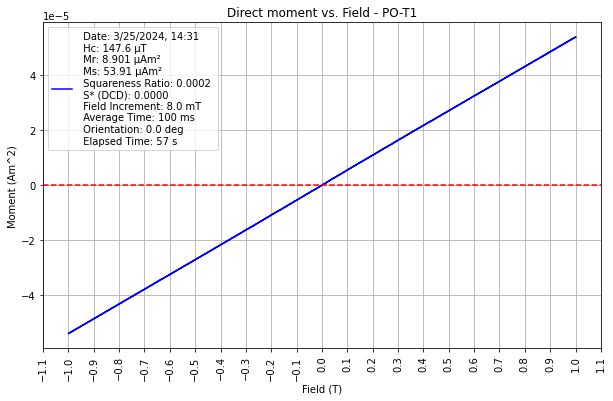

In [95]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO farm ex citu PO-T1.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
#plt.scatter(x_values, y_values, color='blue', marker='o', s=10)  # Adjust marker and size as needed
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Moment (Am^2)')
plt.title('Direct moment vs. Field - PO-T1')
plt.grid(True)
plt.legend([' Date: 3/25/2024, 14:31  \n Hc: 147.6 μT \n Mr: 8.901 μAm\u00B2 \n Ms: 53.91 μAm\u00B2 \n Squareness Ratio: 0.0002 \n S* (DCD): 0.0000 \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 57 s'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-T1-hys.png")
plt.show()


## PO Exsitu Tektite T2

#### Hysterisis Loop

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


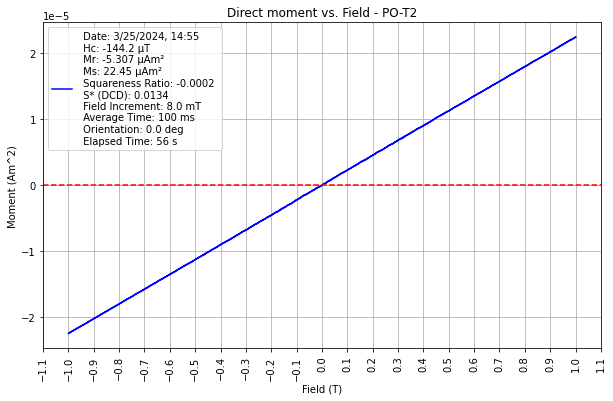

In [96]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO Farm excitu PO-T2.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
#plt.scatter(x_values, y_values, color='blue', marker='o', s=10)  # Adjust marker and size as needed
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Moment (Am^2)')
plt.title('Direct moment vs. Field - PO-T2')
plt.grid(True)
plt.legend([' Date: 3/25/2024, 14:55  \n Hc: -144.2 μT \n Mr: -5.307 μAm\u00B2 \n Ms: 22.45 μAm\u00B2 \n Squareness Ratio: -0.0002 \n S* (DCD): 0.0134 \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-T2-hys.png")
plt.show()


## House of Gems Splash form from Khon Khaen - SPL-KK
### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


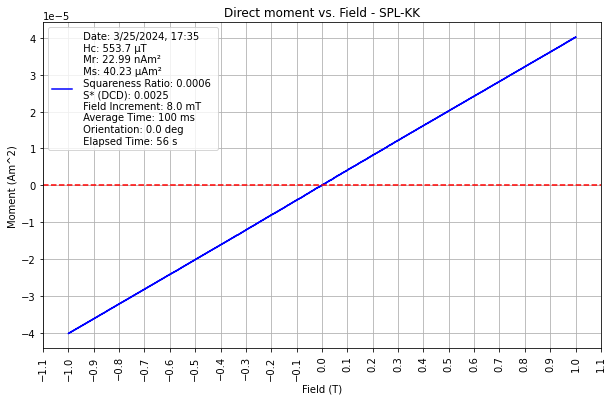

In [97]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/House of gems SPL-KK paramag uncorrected.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
#plt.scatter(x_values, y_values, color='blue', marker='o', s=10)  # Adjust marker and size as needed
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Moment (Am^2)')
plt.title('Direct moment vs. Field - SPL-KK')
plt.grid(True)
plt.legend([' Date: 3/25/2024, 17:35  \n Hc: 553.7 μT \n Mr: 22.99 nAm\u00B2 \n Ms: 40.23 μAm\u00B2 \n Squareness Ratio: 0.0006 \n S* (DCD): 0.0025 \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/SPL-KK-hys.png")
plt.show()


## PO Exsitu Concretion 1

### Hysterisis Loop

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


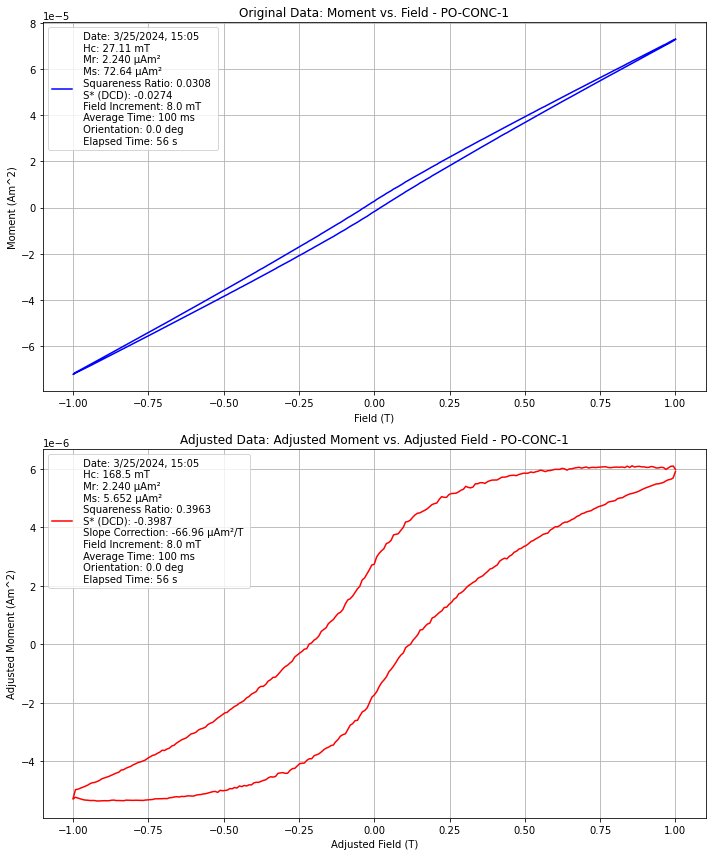

In [99]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO Farm excitu Conc. 1 paramag corrected.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PO-CONC-1')
ax1.grid(True)
ax1.legend([' Date: 3/25/2024, 15:05  \n Hc: 27.11 mT \n Mr: 2.240 μAm\u00B2 \n Ms: 72.64 μAm\u00B2 \n Squareness Ratio: 0.0308 \n S* (DCD): -0.0274 \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PO-CONC-1')
ax2.grid(True)
ax2.legend([' Date: 3/25/2024, 15:05  \n Hc: 168.5 mT \n Mr: 2.240 μAm\u00B2 \n Ms: 5.652 μAm\u00B2 \n Squareness Ratio: 0.3963 \n S* (DCD): -0.3987 \n Slope Correction: -66.96 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])

# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-CONC-1-hys.png")
plt.show()


### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 97 to float: could not convert string to float: ''
Error converting line 98 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


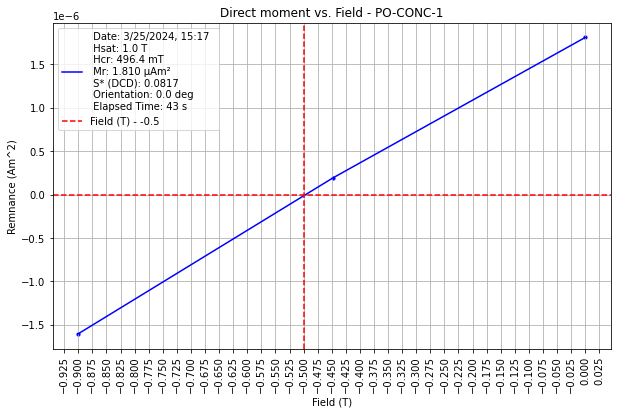

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO Farm excitu Conc. 1.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, linestyle='-', color='blue')
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PO-CONC-1')

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.5, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

# Display x-value at y=0 in the legend
#plt.legend(['x at y=0: {:.6f}'.format(x_at_y_zero)])
plt.legend([' Date: 3/25/2024, 15:17  \n Hsat: 1.0 T \n Hcr: 496.4 mT \n Mr: 1.810 μAm\u00B2 \n S* (DCD): 0.0817 \n Orientation: 0.0 deg \n Elapsed Time: 43 s', 'Field (T) - -0.5'])

plt.grid(True)
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-CONC-1-hcr.png")
plt.show()


In [36]:
y_values, x_values
Mb = Xhf*B+Ms+alpha*B^beta
where χHF is the high-field susceptibility, Ms is the saturation moment, and α and β are approach to saturation coefficients.
the saturation is +5.651756E-06

SyntaxError: invalid syntax (<ipython-input-36-f818240c12e9>, line 3)

## PO Exsitu Concretion 2

### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


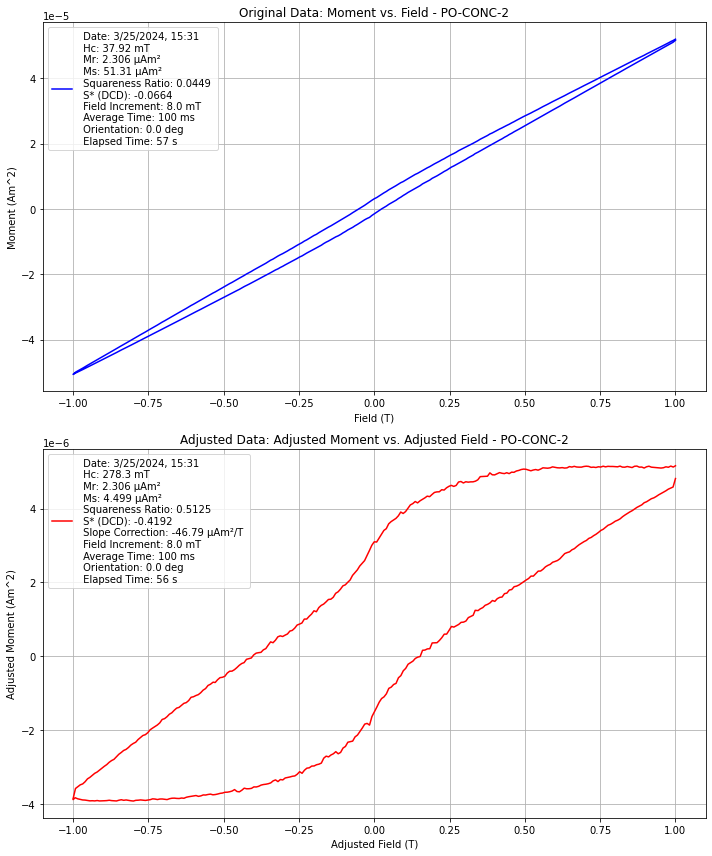

In [98]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO Farm excitu Conc. 2 ferromag corrected.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PO-CONC-2')
ax1.grid(True)
ax1.legend([' Date: 3/25/2024, 15:31  \n Hc: 37.92 mT \n Mr: 2.306 μAm\u00B2 \n Ms: 51.31 μAm\u00B2 \n Squareness Ratio: 0.0449 \n S* (DCD): -0.0664 \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 57 s'])

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PO-CONC-2')
ax2.grid(True)
ax2.legend([' Date: 3/25/2024, 15:31  \n Hc: 278.3 mT \n Mr: 2.306 μAm\u00B2 \n Ms: 4.499 μAm\u00B2 \n Squareness Ratio: 0.5125 \n S* (DCD): -0.4192 \n Slope Correction: -46.79 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])

# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-CONC-2-hys.png")
plt.show()


### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 112 to float: could not convert string to float: ''
Error converting line 113 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


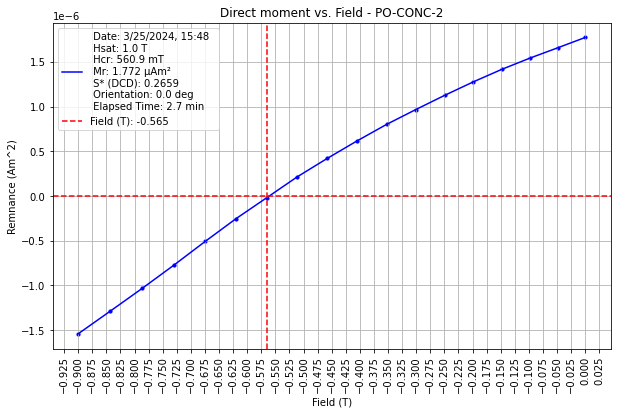

In [79]:
# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO Farm excitu Conc. 2 .hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.565, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PO-CONC-2')
plt.legend([' Date: 3/25/2024, 15:48  \n Hsat: 1.0 T \n Hcr: 560.9 mT \n Mr: 1.772 μAm\u00B2 \n S* (DCD): 0.2659 \n Orientation: 0.0 deg \n Elapsed Time: 2.7 min', 'Field (T): -0.565'])
plt.grid(True)
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-CONC-2-hcr.png")
plt.show()


## PO Exsitu Concretion 3

### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


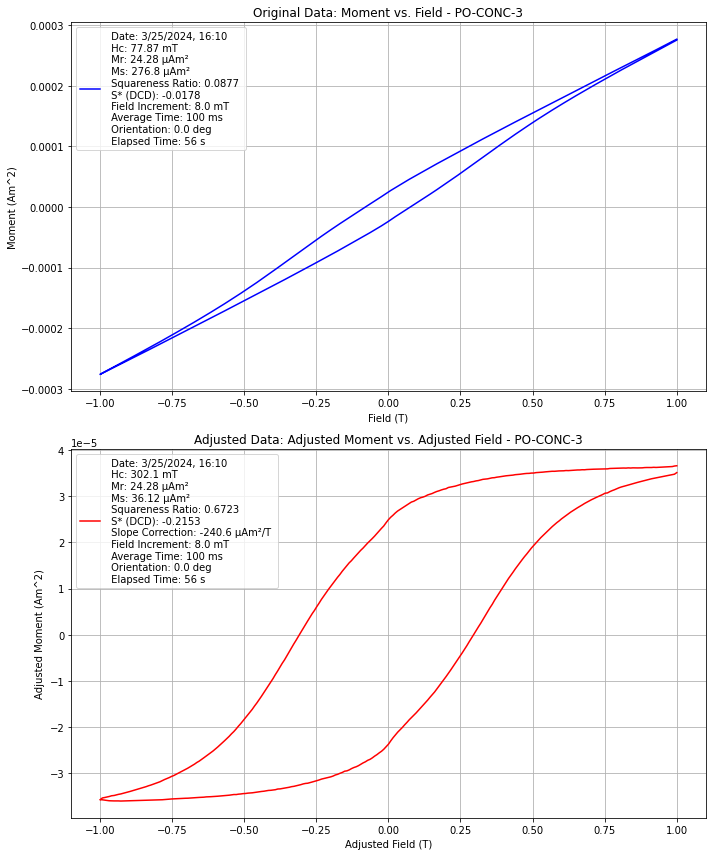

In [100]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO Farm excitu Conc. 3 ferromag corrected.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PO-CONC-3')
ax1.grid(True)
ax1.legend([' Date: 3/25/2024, 16:10  \n Hc: 77.87 mT \n Mr: 24.28 μAm\u00B2 \n Ms: 276.8 μAm\u00B2 \n Squareness Ratio: 0.0877 \n S* (DCD): -0.0178 \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PO-CONC-3')
ax2.grid(True)
ax2.legend([' Date: 3/25/2024, 16:10  \n Hc: 302.1 mT \n Mr: 24.28 μAm\u00B2 \n Ms: 36.12 μAm\u00B2 \n Squareness Ratio: 0.6723 \n S* (DCD): -0.2153 \n Slope Correction: -240.6 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-CONC-3-hys.png")
plt.show()


### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 107 to float: could not convert string to float: ''
Error converting line 108 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


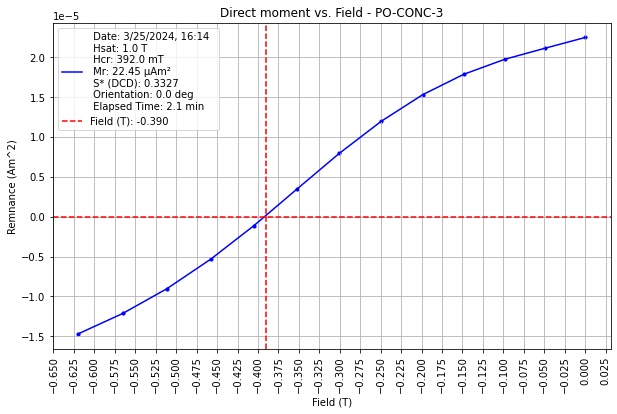

In [80]:
# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO Farm excitu Conc. 3 ferromag corrected.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.390, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')


plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PO-CONC-3')
plt.legend([' Date: 3/25/2024, 16:14  \n Hsat: 1.0 T \n Hcr: 392.0 mT \n Mr: 22.45 μAm\u00B2 \n S* (DCD): 0.3327 \n Orientation: 0.0 deg \n Elapsed Time: 2.1 min', 'Field (T): -0.390'])

plt.grid(True)
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-CONC-3-hcr.png")
plt.show()


## PO Exsitu Concretion 4

### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


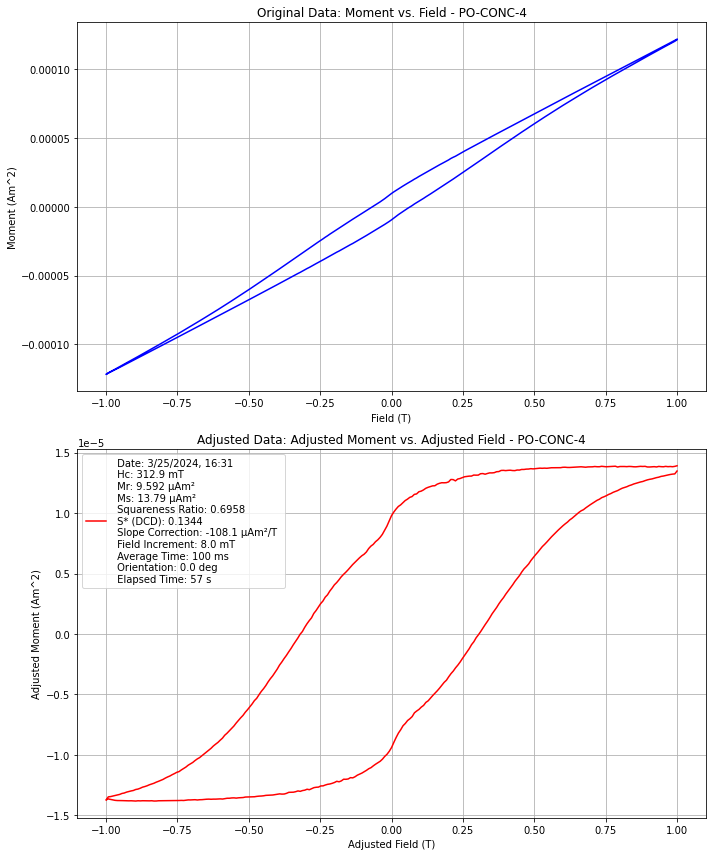

In [101]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO Farm excitu Conc. 4 ferromag corrected.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PO-CONC-4')
ax1.grid(True)


# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PO-CONC-4')
ax2.grid(True)
ax2.legend([' Date: 3/25/2024, 16:31  \n Hc: 312.9 mT \n Mr: 9.592 μAm\u00B2 \n Ms: 13.79 μAm\u00B2 \n Squareness Ratio: 0.6958 \n S* (DCD): 0.1344 \n Slope Correction: -108.1 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 57 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-CONC-4-hys.png")

plt.show()

### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 105 to float: could not convert string to float: ''
Error converting line 106 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


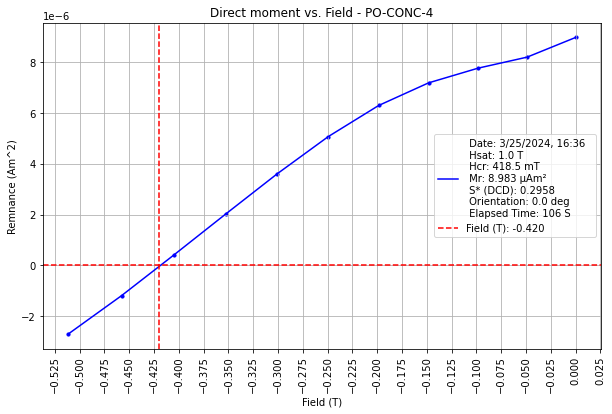

In [81]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Tektites/PO Farm excitu Conc. 4 ferromag corrected.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.420, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PO-CONC-4')
plt.legend([' Date: 3/25/2024, 16:36  \n Hsat: 1.0 T \n Hcr: 418.5 mT \n Mr: 8.983 μAm\u00B2 \n S* (DCD): 0.2958 \n Orientation: 0.0 deg \n Elapsed Time: 106 S', 'Field (T): -0.420'])
plt.grid(True)
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PO-CONC-4-hcr.png")
plt.show()


# Basalts

## NWF24-C-P8

### Top

#### Hysterisis - large chip

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


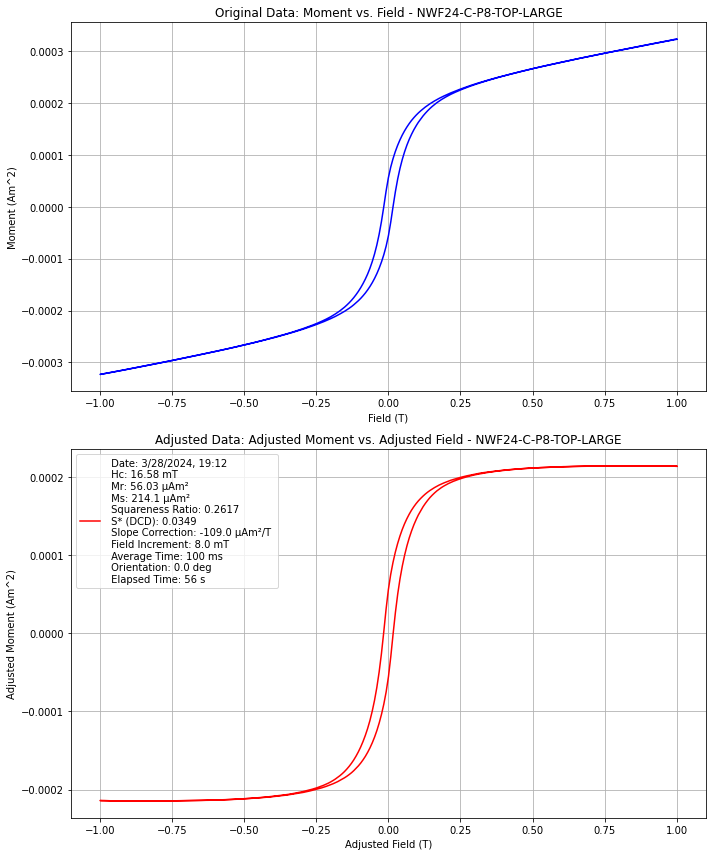

In [102]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/NFW24-C-P8 top large chip.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - NWF24-C-P8-TOP-LARGE')
ax1.grid(True)


# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - NWF24-C-P8-TOP-LARGE')
ax2.grid(True)
ax2.legend([' Date: 3/28/2024, 19:12  \n Hc: 16.58 mT \n Mr: 56.03 μAm\u00B2 \n Ms: 214.1 μAm\u00B2 \n Squareness Ratio: 0.2617 \n S* (DCD): 0.0349 \n Slope Correction: -109.0 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/NWF24-C-P8-TOP-LARGE-hys.png")

plt.show()

#### Hcr - large chip

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 112 to float: could not convert string to float: ''
Error converting line 113 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


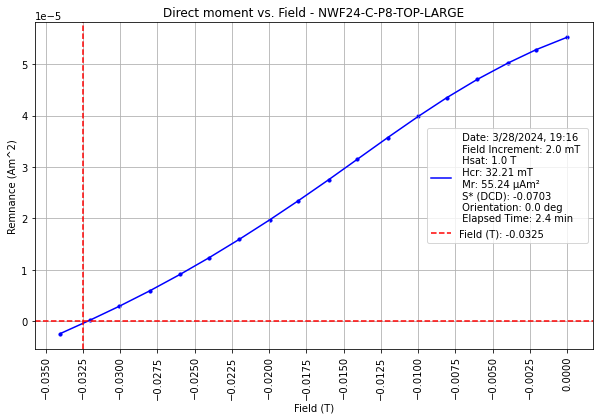

In [82]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/NFW24-C-P8 top large chip.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0325, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - NWF24-C-P8-TOP-LARGE')
plt.legend([' Date: 3/28/2024, 19:16 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 32.21 mT \n Mr: 55.24 μAm\u00B2 \n S* (DCD): -0.0703 \n Orientation: 0.0 deg \n Elapsed Time: 2.4 min', 'Field (T): -0.0325'])
plt.grid(True)
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/NWF24-C-P8-TOP-LARGE-hcr.png")
plt.show()


#### Hysterisis - small chip

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


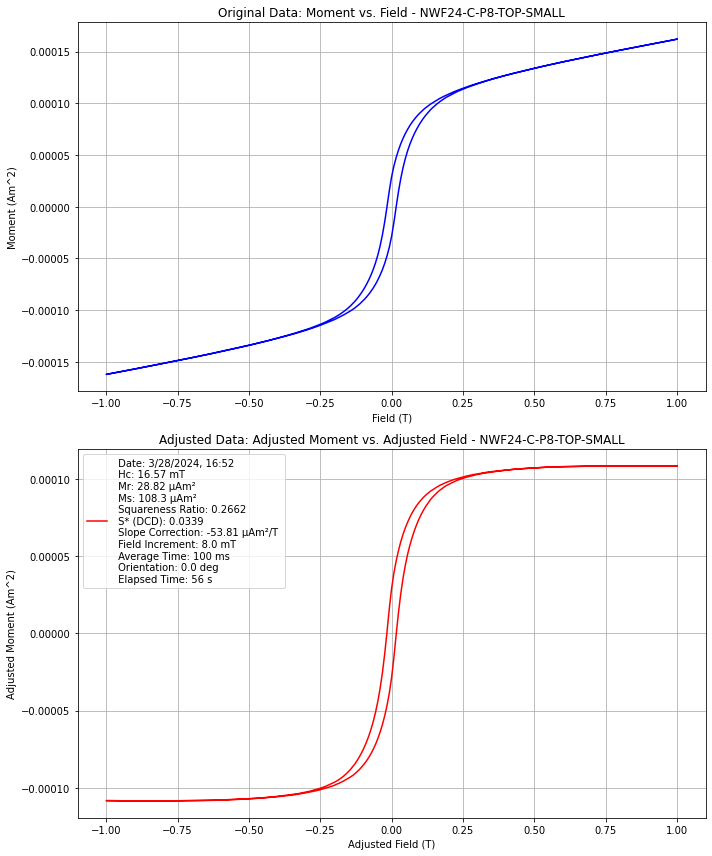

In [103]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/NWF24-C-P8 weathered top.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - NWF24-C-P8-TOP-SMALL')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - NWF24-C-P8-TOP-SMALL')
ax2.grid(True)
ax2.legend([' Date: 3/28/2024, 16:52  \n Hc: 16.57 mT \n Mr: 28.82 μAm\u00B2 \n Ms: 108.3 μAm\u00B2 \n Squareness Ratio: 0.2662 \n S* (DCD): 0.0339 \n Slope Correction: -53.81 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/NWF24-C-P8-TOP-SMALL-hys.png")
plt.show()

#### Hcr - small chip

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 115 to float: could not convert string to float: ''
Error converting line 116 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


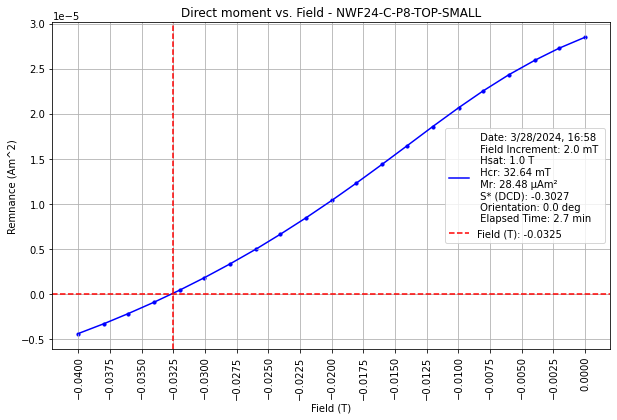

In [83]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/NWF24-C-P8 weathered top.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0325, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - NWF24-C-P8-TOP-SMALL')
plt.grid(True)
plt.legend([' Date: 3/28/2024, 16:58 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 32.64 mT \n Mr: 28.48 μAm\u00B2 \n S* (DCD): -0.3027 \n Orientation: 0.0 deg \n Elapsed Time: 2.7 min', 'Field (T): -0.0325'])
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/NWF24-C-P8-TOP-SMALL-hcr.png")
plt.show()


### Bottom

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


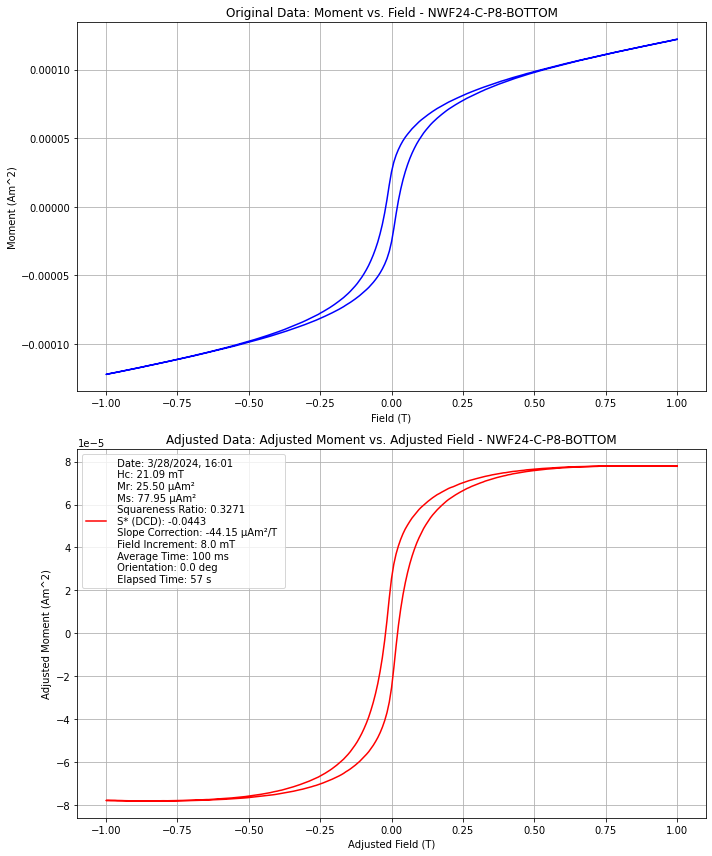

In [104]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/NWF24-C-P8 bottom.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - NWF24-C-P8-BOTTOM')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - NWF24-C-P8-BOTTOM')
ax2.grid(True)
ax2.legend([' Date: 3/28/2024, 16:01  \n Hc: 21.09 mT \n Mr: 25.50 μAm\u00B2 \n Ms: 77.95 μAm\u00B2 \n Squareness Ratio: 0.3271 \n S* (DCD): -0.0443 \n Slope Correction: -44.15 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 57 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/NWF24-C-P8-BOTTOM-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 119 to float: could not convert string to float: ''
Error converting line 120 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


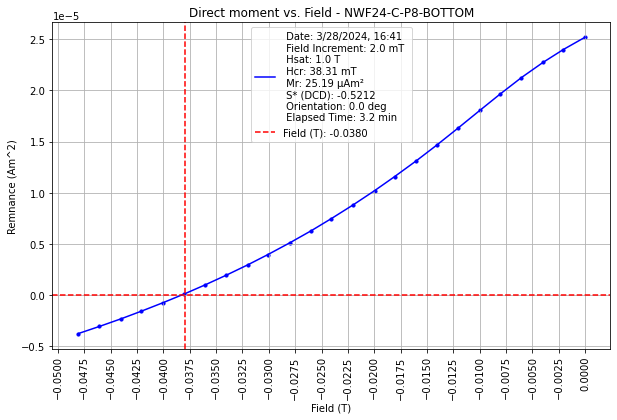

In [84]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/NWF24-C-P8 bottom.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0380, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - NWF24-C-P8-BOTTOM')
plt.grid(True)
plt.legend([' Date: 3/28/2024, 16:41 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 38.31 mT \n Mr: 25.19 μAm\u00B2 \n S* (DCD): -0.5212 \n Orientation: 0.0 deg \n Elapsed Time: 3.2 min', 'Field (T): -0.0380'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/NWF24-C-P8-BOTTOM-hcr.png")
plt.show()


## PKQ24-A-P2A

### Top

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


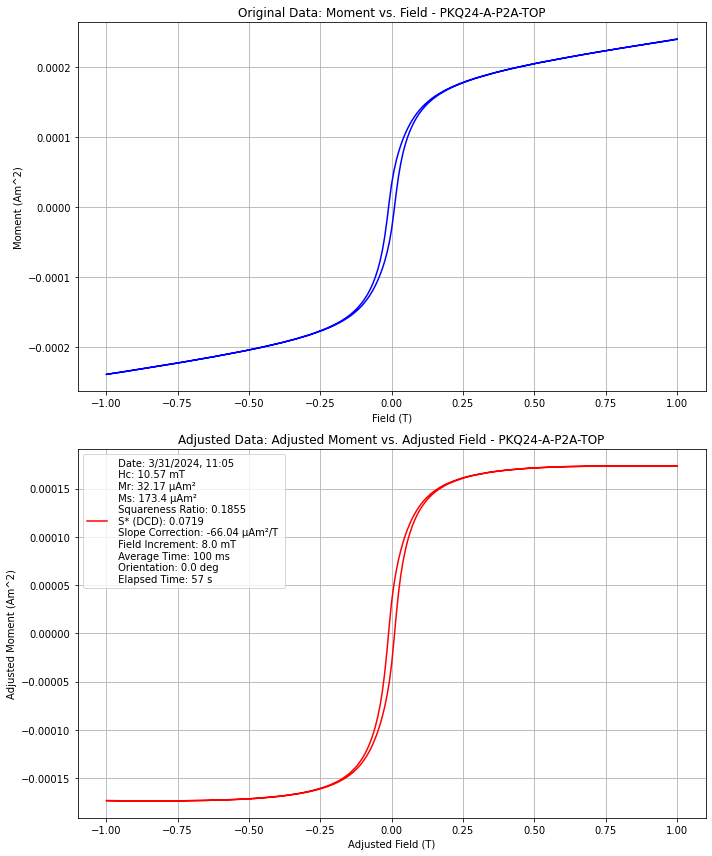

In [106]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-A-P2A top.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKQ24-A-P2A-TOP')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKQ24-A-P2A-TOP')
ax2.grid(True)
ax2.legend([' Date: 3/31/2024, 11:05  \n Hc: 10.57 mT \n Mr: 32.17 μAm\u00B2 \n Ms: 173.4 μAm\u00B2 \n Squareness Ratio: 0.1855 \n S* (DCD): 0.0719 \n Slope Correction: -66.04 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 57 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P2A-TOP-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 120 to float: could not convert string to float: ''
Error converting line 121 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


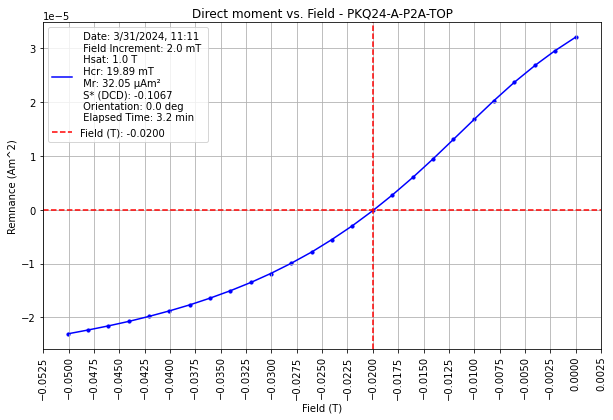

In [85]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-A-P2A weathered top.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0200, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKQ24-A-P2A-TOP')
plt.grid(True)
plt.legend([' Date: 3/31/2024, 11:11 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 19.89 mT \n Mr: 32.05 μAm\u00B2 \n S* (DCD): -0.1067 \n Orientation: 0.0 deg \n Elapsed Time: 3.2 min', 'Field (T): -0.0200'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P2A-TOP-hcr.png")
plt.show()


### Bottom

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


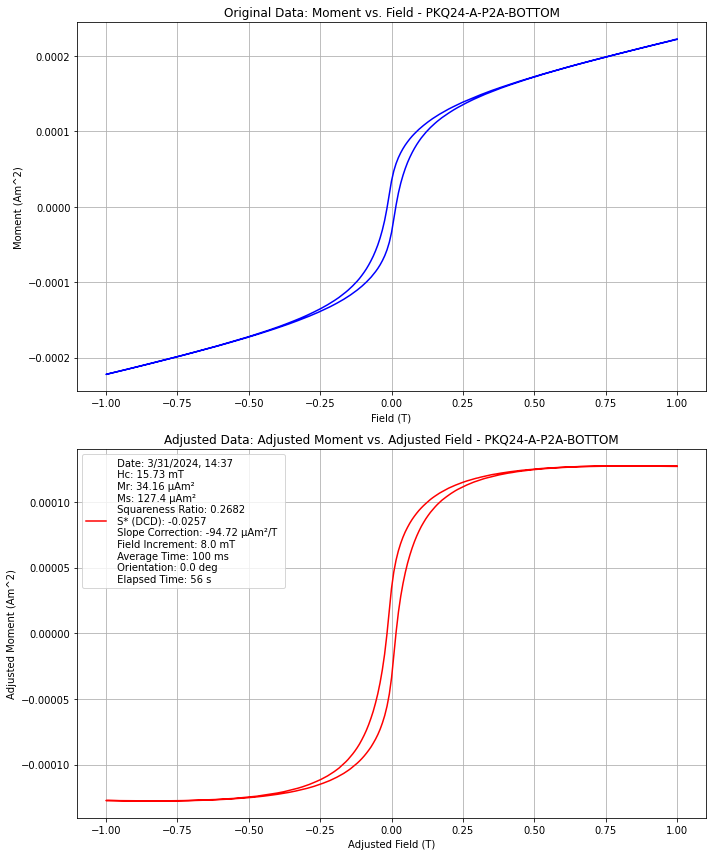

In [107]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-A-P2A bottom.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKQ24-A-P2A-BOTTOM')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKQ24-A-P2A-BOTTOM')
ax2.grid(True)
ax2.legend([' Date: 3/31/2024, 14:37  \n Hc: 15.73 mT \n Mr: 34.16 μAm\u00B2 \n Ms: 127.4 μAm\u00B2 \n Squareness Ratio: 0.2682 \n S* (DCD): -0.0257 \n Slope Correction: -94.72 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P2A-BOTTOM-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 132 to float: could not convert string to float: ''
Error converting line 133 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


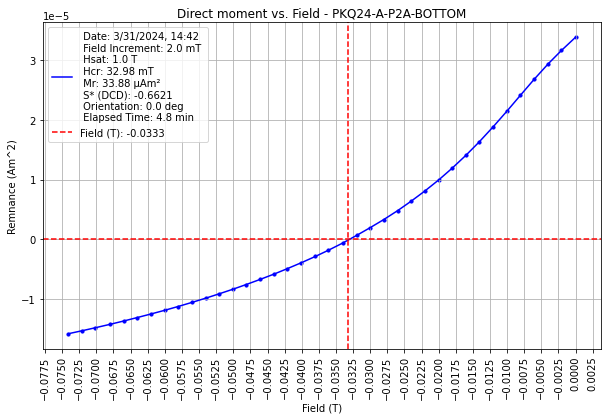

In [86]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-A-P2A bottom.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0333, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKQ24-A-P2A-BOTTOM')
plt.grid(True)
plt.legend([' Date: 3/31/2024, 14:42 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 32.98 mT \n Mr: 33.88 μAm\u00B2 \n S* (DCD): -0.6621 \n Orientation: 0.0 deg \n Elapsed Time: 4.8 min', 'Field (T): -0.0333'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P2A-BOTTOM-hcr.png")
plt.show()


## PKQ24-A-P5A

### Top

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


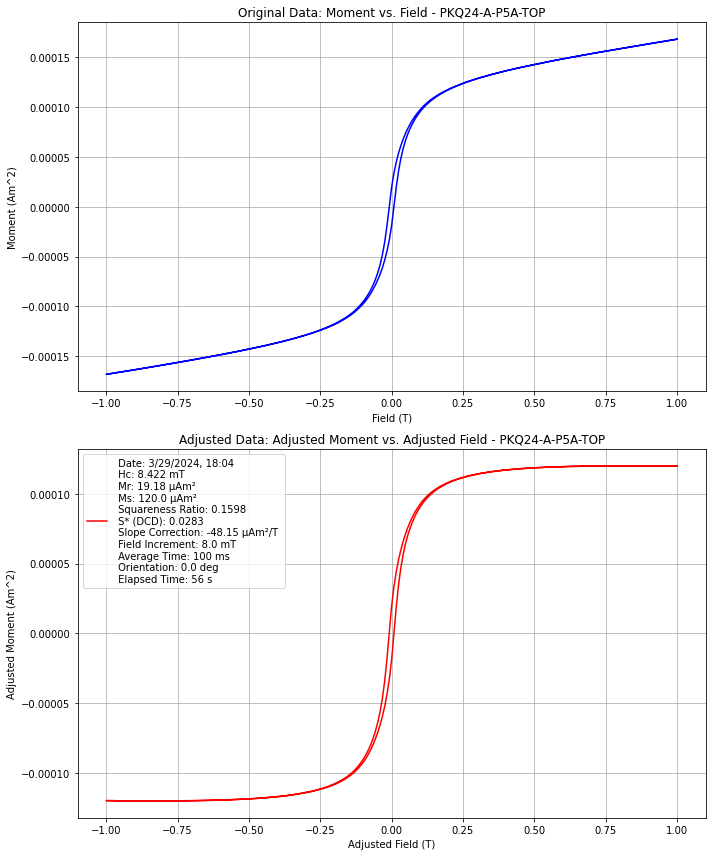

In [108]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-A-P5A top.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKQ24-A-P5A-TOP')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKQ24-A-P5A-TOP')
ax2.grid(True)
ax2.legend([' Date: 3/29/2024, 18:04  \n Hc: 8.422 mT \n Mr: 19.18 μAm\u00B2 \n Ms: 120.0 μAm\u00B2 \n Squareness Ratio: 0.1598 \n S* (DCD): 0.0283 \n Slope Correction: -48.15 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P5A-TOP-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 107 to float: could not convert string to float: ''
Error converting line 108 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


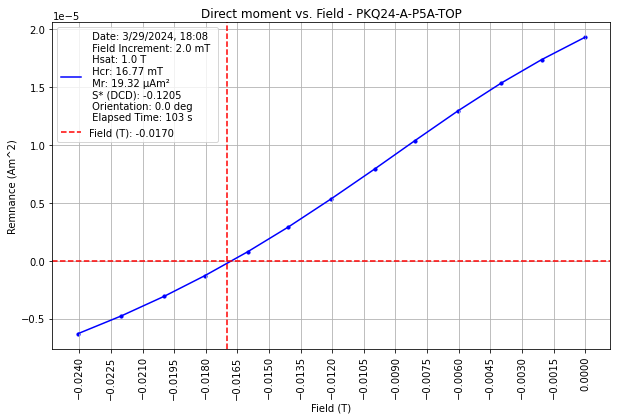

In [87]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-A-P5A top.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0170, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0015))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKQ24-A-P5A-TOP')
plt.grid(True)
plt.legend([' Date: 3/29/2024, 18:08 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 16.77 mT \n Mr: 19.32 μAm\u00B2 \n S* (DCD): -0.1205 \n Orientation: 0.0 deg \n Elapsed Time: 103 s', 'Field (T): -0.0170'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P5A-TOP-hcr.png")
plt.show()


### Bottom

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


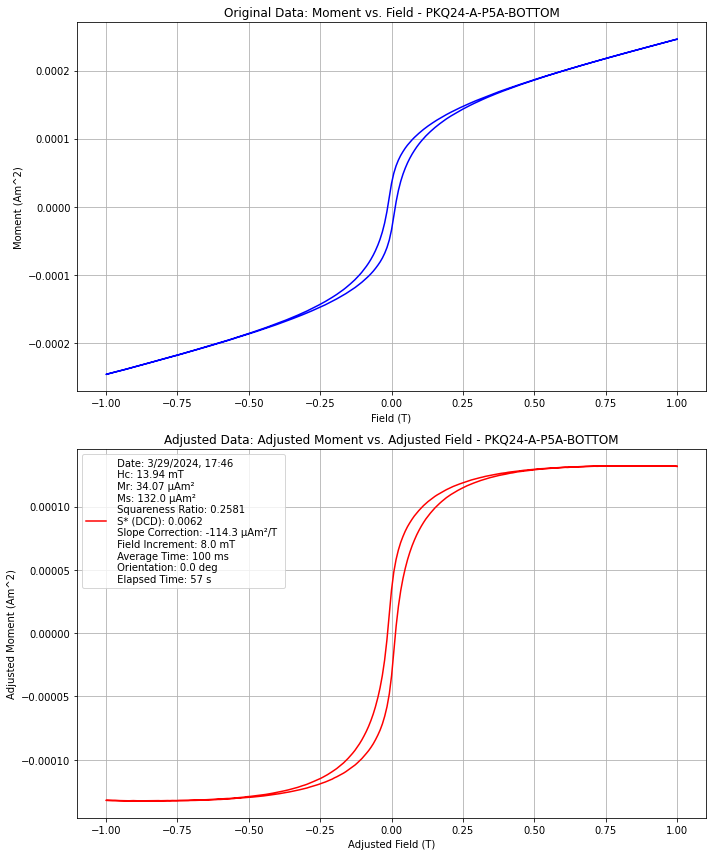

In [109]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-A-P5A bottom.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKQ24-A-P5A-BOTTOM')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKQ24-A-P5A-BOTTOM')
ax2.grid(True)
ax2.legend([' Date: 3/29/2024, 17:46  \n Hc: 13.94 mT \n Mr: 34.07 μAm\u00B2 \n Ms: 132.0 μAm\u00B2 \n Squareness Ratio: 0.2581 \n S* (DCD): 0.0062 \n Slope Correction: -114.3 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 57 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P5A-BOTTOM-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 114 to float: could not convert string to float: ''
Error converting line 115 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


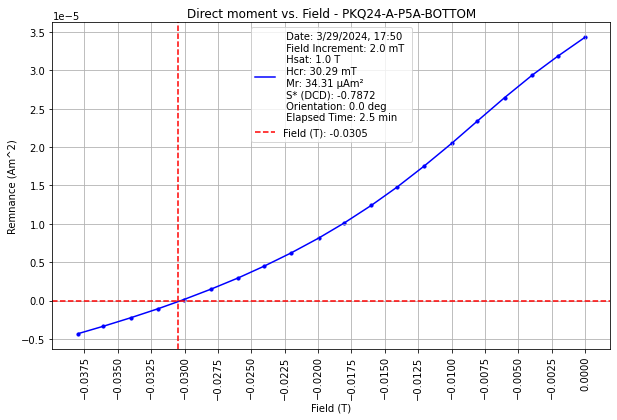

In [88]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-A-P5A bottom.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0305, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKQ24-A-P5A-BOTTOM')
plt.grid(True)
plt.legend([' Date: 3/29/2024, 17:50 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 30.29 mT \n Mr: 34.31 μAm\u00B2 \n S* (DCD): -0.7872 \n Orientation: 0.0 deg \n Elapsed Time: 2.5 min', 'Field (T): -0.0305'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P5A-BOTTOM-hcr.png")
plt.show()


## PKQ24-A-P5C

### Top

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


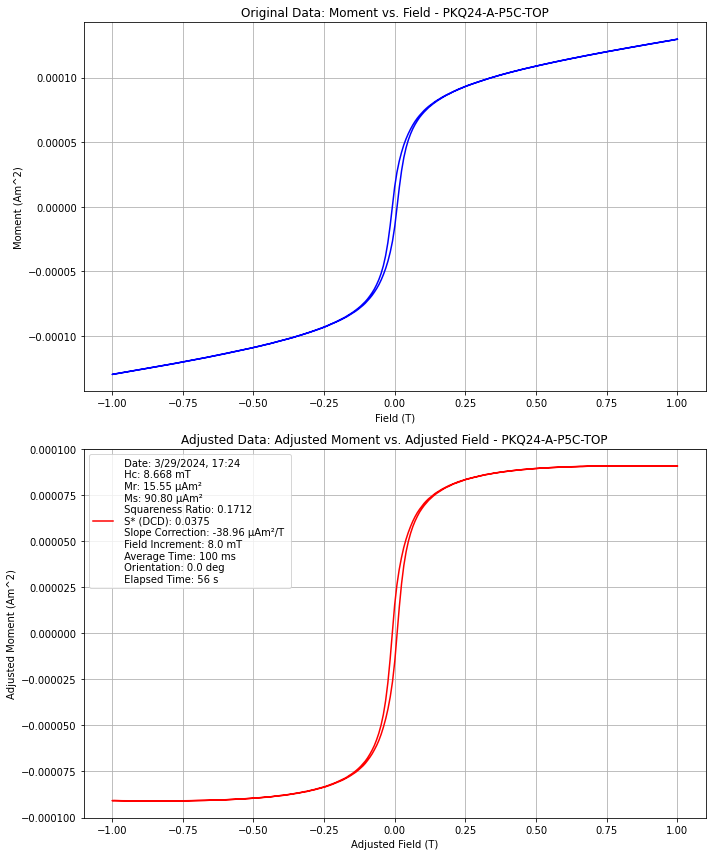

In [125]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-AP-5C top.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKQ24-A-P5C-TOP')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKQ24-A-P5C-TOP')
ax2.grid(True)
ax2.legend([' Date: 3/29/2024, 17:24  \n Hc: 8.668 mT \n Mr: 15.55 μAm\u00B2 \n Ms: 90.80 μAm\u00B2 \n Squareness Ratio: 0.1712 \n S* (DCD): 0.0375 \n Slope Correction: -38.96 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P5C-TOP-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 105 to float: could not convert string to float: ''
Error converting line 106 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


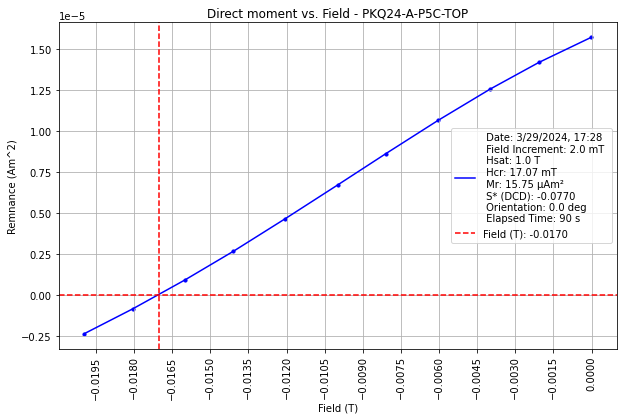

In [126]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-AP-5C top.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0170, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0015))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKQ24-A-P5C-TOP')
plt.grid(True)
plt.legend([' Date: 3/29/2024, 17:28 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 17.07 mT \n Mr: 15.75 μAm\u00B2 \n S* (DCD): -0.0770 \n Orientation: 0.0 deg \n Elapsed Time: 90 s', 'Field (T): -0.0170'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P5C-TOP-hcr.png")
plt.show()


### Bottom

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


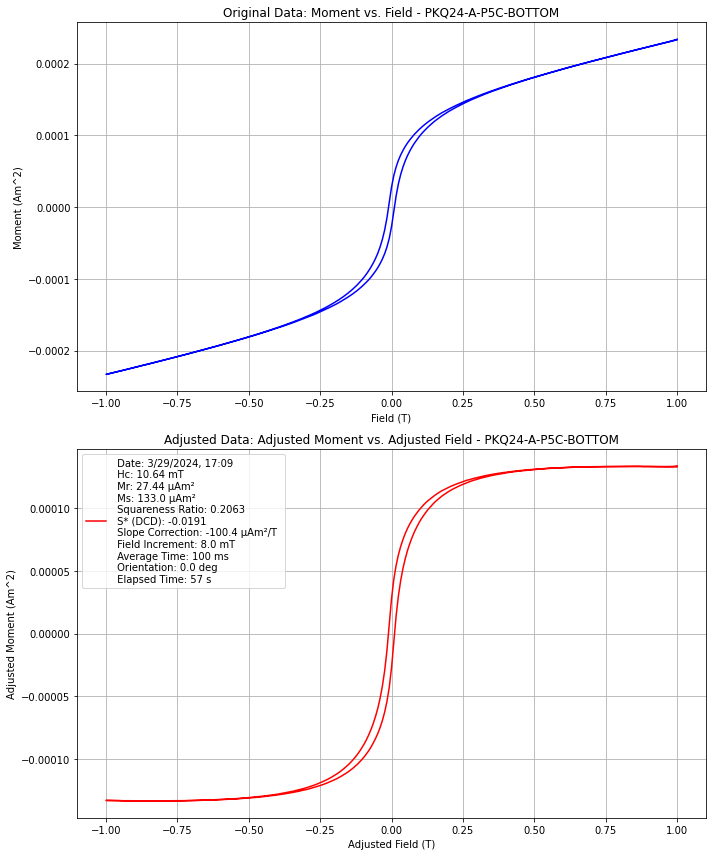

In [110]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-AP-5C bottom.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKQ24-A-P5C-BOTTOM')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKQ24-A-P5C-BOTTOM')
ax2.grid(True)
ax2.legend([' Date: 3/29/2024, 17:09  \n Hc: 10.64 mT \n Mr: 27.44 μAm\u00B2 \n Ms: 133.0 μAm\u00B2 \n Squareness Ratio: 0.2063 \n S* (DCD): -0.0191 \n Slope Correction: -100.4 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 57 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P5C-BOTTOM-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 114 to float: could not convert string to float: ''
Error converting line 115 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


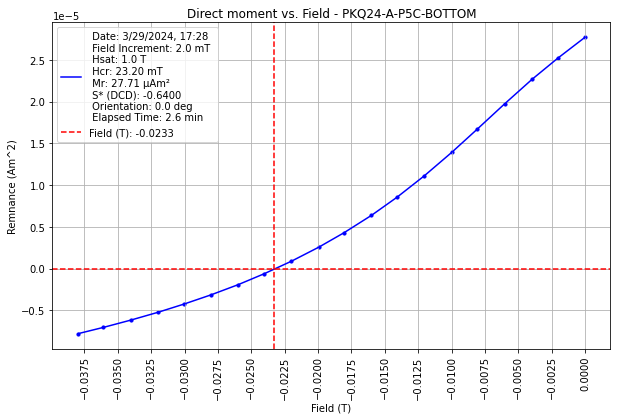

In [90]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-AP-5C bottom.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0233, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKQ24-A-P5C-BOTTOM')
plt.grid(True)
plt.legend([' Date: 3/29/2024, 17:28 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 23.20 mT \n Mr: 27.71 μAm\u00B2 \n S* (DCD): -0.6400 \n Orientation: 0.0 deg \n Elapsed Time: 2.6 min', 'Field (T): -0.0233'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-A-P5C-BOTTOM-hcr.png")
plt.show()


## PKS24-HB-P1 > confirm name PKQ or PKS

### Top

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


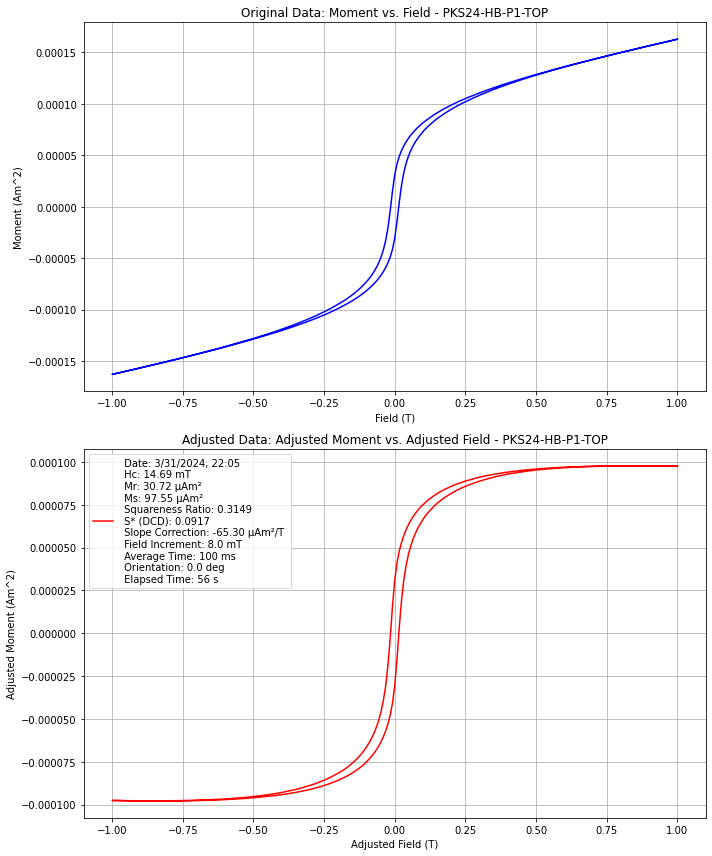

In [130]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-HB-P1 top unweathered.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKS24-HB-P1-TOP')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKS24-HB-P1-TOP')
ax2.grid(True)
ax2.legend([' Date: 3/31/2024, 22:05  \n Hc: 14.69 mT \n Mr: 30.72 μAm\u00B2 \n Ms: 97.55 μAm\u00B2 \n Squareness Ratio: 0.3149 \n S* (DCD): 0.0917 \n Slope Correction: -65.30 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-HB-P1-TOP-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 110 to float: could not convert string to float: ''
Error converting line 111 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


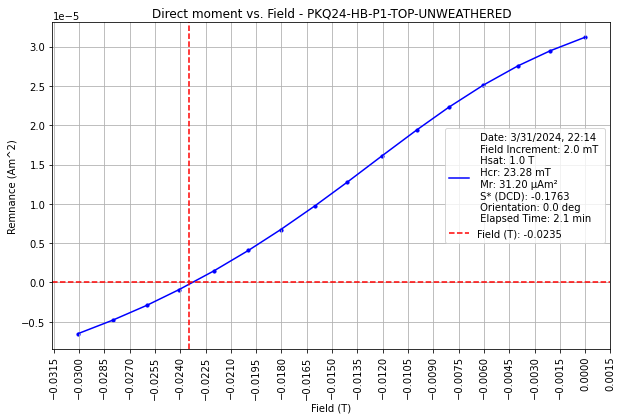

In [129]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-HB-P1 top unweathered.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0235, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0015))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKQ24-HB-P1-TOP-UNWEATHERED')
plt.grid(True)
plt.legend([' Date: 3/31/2024, 22:14 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 23.28 mT \n Mr: 31.20 μAm\u00B2 \n S* (DCD): -0.1763 \n Orientation: 0.0 deg \n Elapsed Time: 2.1 min', 'Field (T): -0.0235'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-HB-P1-TOP-hcr.png")
plt.show()


#### FORC

Error converting line 85 to float: could not convert string to float: 'Field         Moment'
Error converting line 86 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 88 to float: could not convert string to float: ''
Error converting line 90 to float: could not convert string to float: ''
Error converting line 92 to float: could not convert string to float: ''
Error converting line 96 to float: could not convert string to float: ''
Error converting line 98 to float: could not convert string to float: ''
Error converting line 104 to float: could not convert string to float: ''
Error converting line 106 to float: could not convert string to float: ''
Error converting line 114 to float: could not convert string to float: ''
Error converting line 116 to float: could not convert string to float: ''
Error converting line 126 to float: could not convert string to float: ''
Error converting line 128 to float: could not convert string to float: ''
Error c

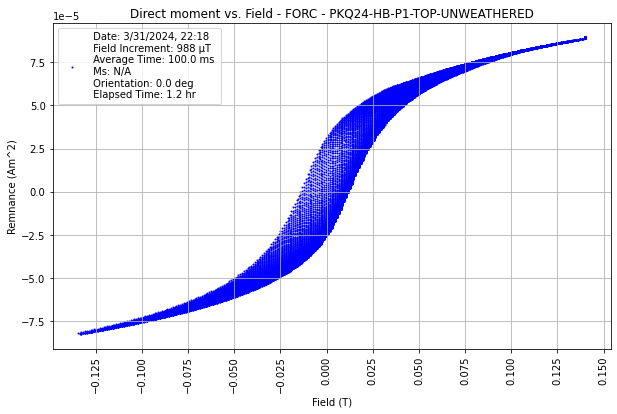

In [149]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-HB-P1 top unweathered.frc"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[85:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 85} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=1)  # Adjust marker
#plt.plot(x_values, y_values, linestyle='-', color='blue') 

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - FORC - PKQ24-HB-P1-TOP-UNWEATHERED')
plt.grid(True)
plt.legend([' Date: 3/31/2024, 22:18 \n Field Increment: 988 μT \n Average Time: 100.0 ms \n Ms: N/A \n Orientation: 0.0 deg \n Elapsed Time: 1.2 hr'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-HB-P1-TOP-FORC.png")
plt.show()


### Bottom

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


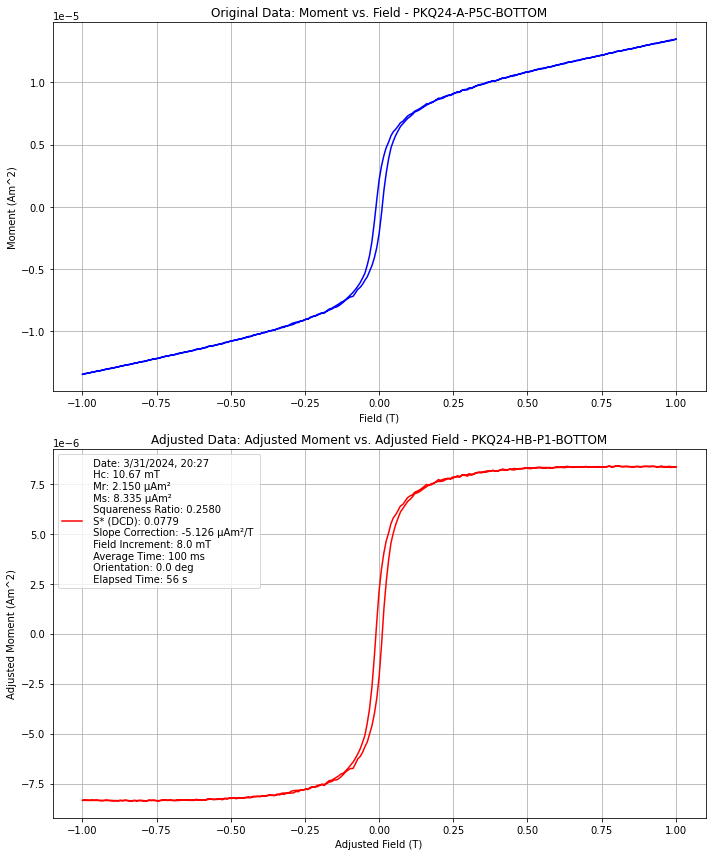

In [131]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-HB-P1 bottom weathered.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKQ24-A-P5C-BOTTOM')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKQ24-HB-P1-BOTTOM')
ax2.grid(True)
ax2.legend([' Date: 3/31/2024, 20:27 \n Hc: 10.67 mT \n Mr: 2.150 μAm\u00B2 \n Ms: 8.335 μAm\u00B2 \n Squareness Ratio: 0.2580 \n S* (DCD): 0.0779 \n Slope Correction: -5.126 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-HB-P1-BOTTOM-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 106 to float: could not convert string to float: ''
Error converting line 107 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


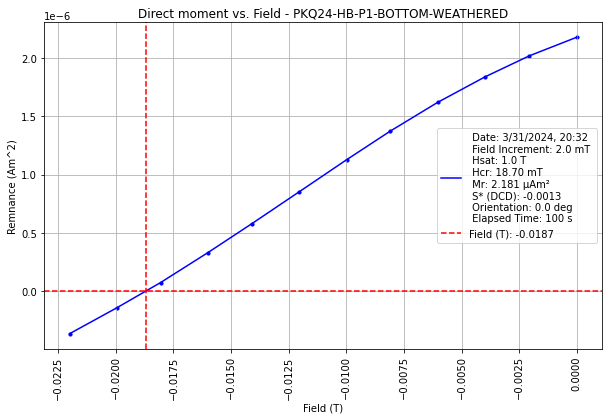

In [137]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKS24-HB-P1 bottom weathered.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0187, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKQ24-HB-P1-BOTTOM-WEATHERED')
plt.grid(True)
plt.legend([' Date: 3/31/2024, 20:32 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 18.70 mT \n Mr: 2.181 μAm\u00B2 \n S* (DCD): -0.0013 \n Orientation: 0.0 deg \n Elapsed Time: 100 s', 'Field (T): -0.0187'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-HB-P1-BOTTOM-hcr.png")
plt.show()


#### FORC

Error converting line 85 to float: could not convert string to float: 'Field         Moment'
Error converting line 86 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 88 to float: could not convert string to float: ''
Error converting line 90 to float: could not convert string to float: ''
Error converting line 92 to float: could not convert string to float: ''
Error converting line 96 to float: could not convert string to float: ''
Error converting line 98 to float: could not convert string to float: ''
Error converting line 104 to float: could not convert string to float: ''
Error converting line 106 to float: could not convert string to float: ''
Error converting line 114 to float: could not convert string to float: ''
Error converting line 116 to float: could not convert string to float: ''
Error converting line 126 to float: could not convert string to float: ''
Error converting line 128 to float: could not convert string to float: ''
Error c

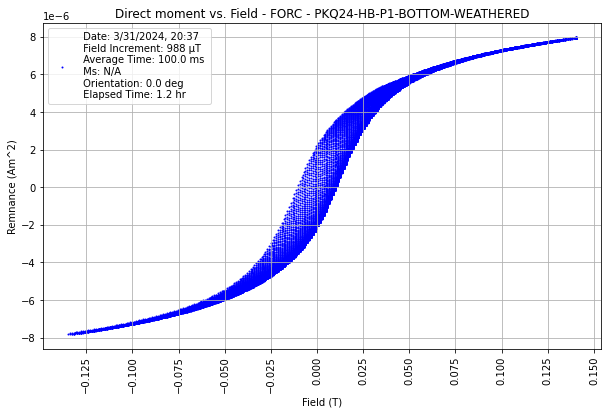

In [150]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKS24-HB-P1 bottom weathered.frc"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[85:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 85} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=1)  # Adjust marker
#plt.plot(x_values, y_values, linestyle='-', color='blue') 

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - FORC - PKQ24-HB-P1-BOTTOM-WEATHERED')
plt.grid(True)
plt.legend([' Date: 3/31/2024, 20:37 \n Field Increment: 988 μT \n Average Time: 100.0 ms \n Ms: N/A \n Orientation: 0.0 deg \n Elapsed Time: 1.2 hr'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-HB-P1-BOTTOM-WEATHERED-FORC.png")
plt.show()


## PKS24-BA-P1

### Top

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


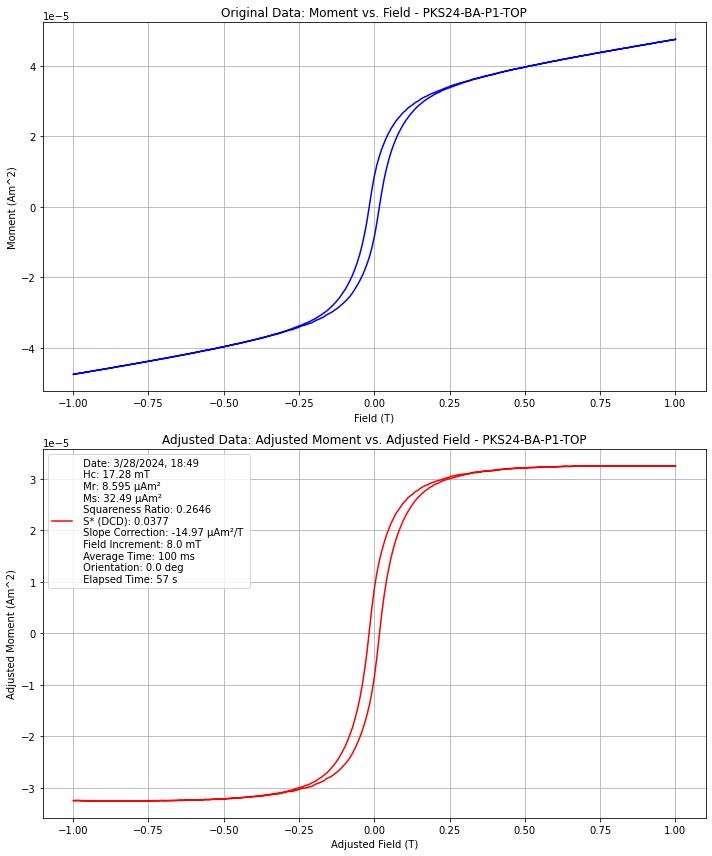

In [151]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKS24-BA-P1 top small chip.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKS24-BA-P1-TOP')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKS24-BA-P1-TOP')
ax2.grid(True)
ax2.legend([' Date: 3/28/2024, 18:49  \n Hc: 17.28 mT \n Mr: 8.595 μAm\u00B2 \n Ms: 32.49 μAm\u00B2 \n Squareness Ratio: 0.2646 \n S* (DCD): 0.0377 \n Slope Correction: -14.97 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 57 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKS24-BA-P1-TOP-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 119 to float: could not convert string to float: ''
Error converting line 120 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


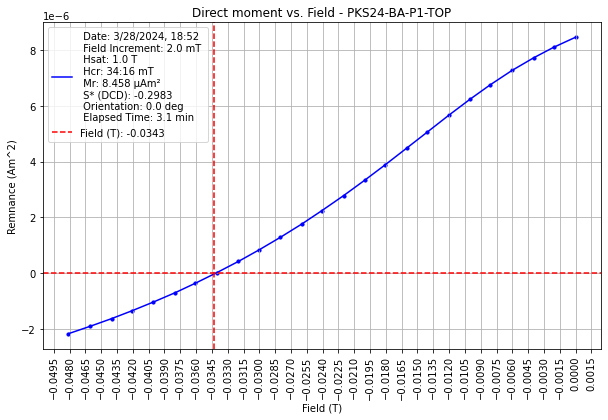

In [154]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKS24-BA-P1 top small chip.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0343, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.0015))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKS24-BA-P1-TOP')
plt.grid(True)
plt.legend([' Date: 3/28/2024, 18:52 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 34:16 mT \n Mr: 8.458 μAm\u00B2 \n S* (DCD): -0.2983 \n Orientation: 0.0 deg \n Elapsed Time: 3.1 min', 'Field (T): -0.0343'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKS24-BA-P1-TOP-hcr.png")
plt.show()


#### FORC

Error converting line 85 to float: could not convert string to float: 'Field         Moment'
Error converting line 86 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 88 to float: could not convert string to float: ''
Error converting line 90 to float: could not convert string to float: ''
Error converting line 92 to float: could not convert string to float: ''
Error converting line 96 to float: could not convert string to float: ''
Error converting line 98 to float: could not convert string to float: ''
Error converting line 104 to float: could not convert string to float: ''
Error converting line 106 to float: could not convert string to float: ''
Error converting line 114 to float: could not convert string to float: ''
Error converting line 116 to float: could not convert string to float: ''
Error converting line 126 to float: could not convert string to float: ''
Error converting line 128 to float: could not convert string to float: ''
Error c

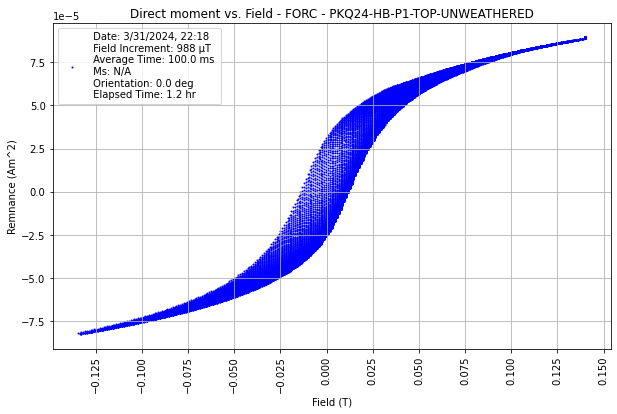

In [149]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKQ24-HB-P1 top unweathered.frc"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[85:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 85} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=1)  # Adjust marker
#plt.plot(x_values, y_values, linestyle='-', color='blue') 

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - FORC - PKQ24-HB-P1-TOP-UNWEATHERED')
plt.grid(True)
plt.legend([' Date: 3/31/2024, 22:18 \n Field Increment: 988 μT \n Average Time: 100.0 ms \n Ms: N/A \n Orientation: 0.0 deg \n Elapsed Time: 1.2 hr'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-HB-P1-TOP-FORC.png")
plt.show()


### Bottom

#### Hysterisis

Error converting line 338 to float: could not convert string to float: ''
Error converting line 590 to float: could not convert string to float: ''
Error converting line 591 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


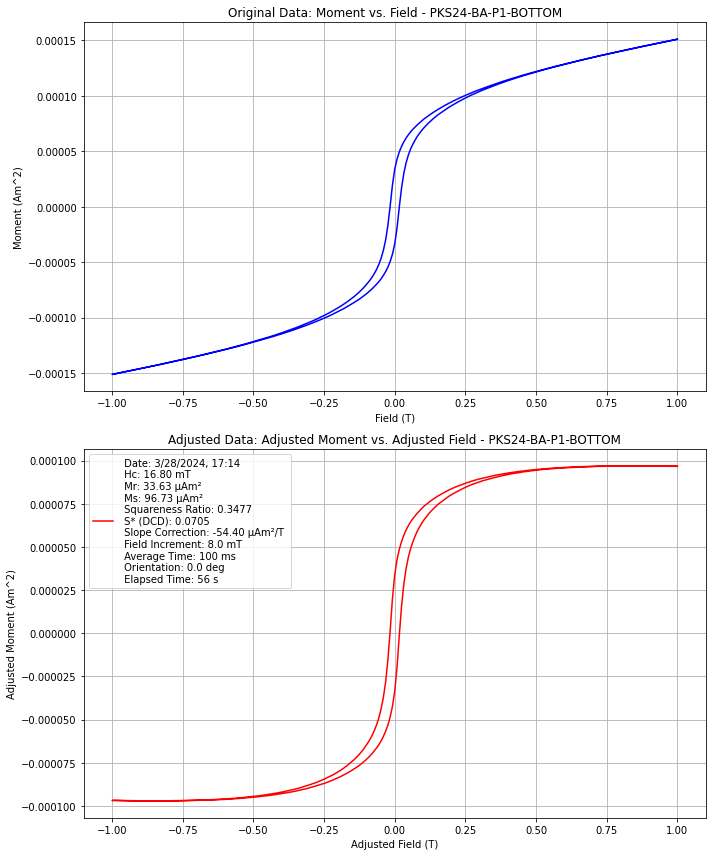

In [155]:
import matplotlib.pyplot as plt

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKS24-BA-P1 bottom.hys"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[86:]  # Starting from line 87

# Initialize lists to store original and adjusted x and y values
x_original = []
y_original = []
x_adjusted = []
y_adjusted = []

# Parse the comma-separated values and extract original and adjusted x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_original.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Field (T)
        y_original.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Original Moment (Am^2)
        x_adjusted.append(float(values[2].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Field (T)
        y_adjusted.append(float(values[3].replace('+', '').replace('E', 'e').replace('-', '-')))  # Adjusted Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 87} to float:", e)

# Create subplots for original and adjusted data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot original data (Field vs. Moment)
ax1.plot(x_original, y_original, linestyle='-', color='blue')
ax1.set_xlabel('Field (T)')
ax1.set_ylabel('Moment (Am^2)')
ax1.set_title('Original Data: Moment vs. Field - PKS24-BA-P1-BOTTOM')
ax1.grid(True)

# Plot adjusted data (Adjusted Field vs. Adjusted Moment)
ax2.plot(x_adjusted, y_adjusted, linestyle='-', color='red')
ax2.set_xlabel('Adjusted Field (T)')
ax2.set_ylabel('Adjusted Moment (Am^2)')
ax2.set_title('Adjusted Data: Adjusted Moment vs. Adjusted Field - PKS24-BA-P1-BOTTOM')
ax2.grid(True)
ax2.legend([' Date: 3/28/2024, 17:14 \n Hc: 16.80 mT \n Mr: 33.63 μAm\u00B2 \n Ms: 96.73 μAm\u00B2 \n Squareness Ratio: 0.3477 \n S* (DCD): 0.0705 \n Slope Correction: -54.40 μAm\u00B2/T \n Field Increment: 8.0 mT \n Average Time: 100 ms \n Orientation: 0.0 deg \n Elapsed Time: 56 s'])


# Adjust layout
plt.tight_layout()
plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKS24-BA-P1-BOTTOM-hys.png")
plt.show()

#### Hcr

Error converting line 93 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 109 to float: could not convert string to float: ''
Error converting line 110 to float: could not convert string to float: 'MicroMag 2900/3900 Data File ends'


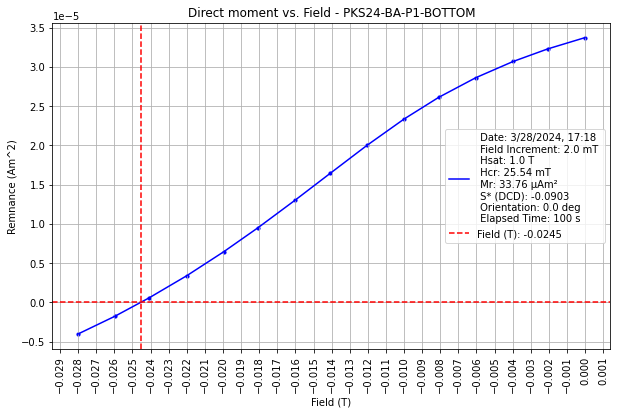

In [160]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKS24-BA-P1 bottom.hcr"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[92:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 93} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=10)  # Adjust marker
plt.plot(x_values, y_values, linestyle='-', color='blue') 

plt.axhline(y=0, color='red', linestyle='--', label='')
plt.axvline(x=-.0245, color='red', linestyle='--', label='')

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.001))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - PKS24-BA-P1-BOTTOM')
plt.grid(True)
plt.legend([' Date: 3/28/2024, 17:18 \n Field Increment: 2.0 mT \n Hsat: 1.0 T \n Hcr: 25.54 mT \n Mr: 33.76 μAm\u00B2 \n S* (DCD): -0.0903 \n Orientation: 0.0 deg \n Elapsed Time: 100 s', 'Field (T): -0.0245'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKS24-BA-P1-BOTTOM-hcr.png")
plt.show()


#### FORC

Error converting line 85 to float: could not convert string to float: 'Field         Moment'
Error converting line 86 to float: could not convert string to float: '(T)          (Am2)'
Error converting line 88 to float: could not convert string to float: ''
Error converting line 90 to float: could not convert string to float: ''
Error converting line 92 to float: could not convert string to float: ''
Error converting line 96 to float: could not convert string to float: ''
Error converting line 98 to float: could not convert string to float: ''
Error converting line 104 to float: could not convert string to float: ''
Error converting line 106 to float: could not convert string to float: ''
Error converting line 114 to float: could not convert string to float: ''
Error converting line 116 to float: could not convert string to float: ''
Error converting line 126 to float: could not convert string to float: ''
Error converting line 128 to float: could not convert string to float: ''
Error c

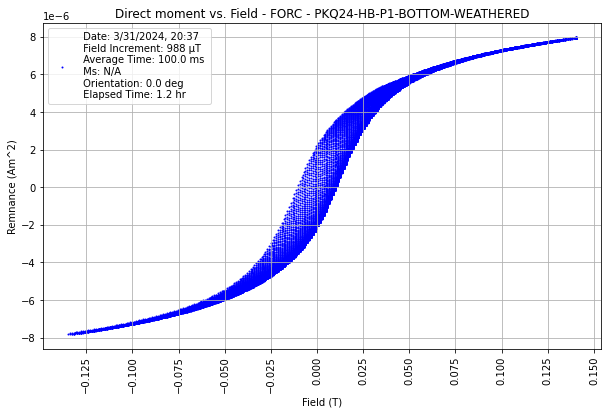

In [150]:
from matplotlib.ticker import MultipleLocator

# Define the file path
file_path = "/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/LaosBasalts/PKS24-HB-P1 bottom weathered.frc"

# Read the lines from the file starting from line 87
with open(file_path, "r") as file:
    lines = file.readlines()[85:]  # Starting from line 87

# Initialize lists to store x and y values
x_values = []
y_values = []

# Parse the comma-separated values and extract x and y values
for idx, line in enumerate(lines):
    values = line.strip().split(",")
    try:
        # Remove '+' and '-' symbols and convert to float
        x_values.append(float(values[0].replace('+', '').replace('E', 'e').replace('-', '-')))  # Field (T)
        y_values.append(float(values[1].replace('+', '').replace('E', 'e').replace('-', '-')))  # Moment (Am^2)
    except ValueError as e:
        print(f"Error converting line {idx + 85} to float:", e)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, color='blue', marker='o', linestyle='-', s=1)  # Adjust marker
#plt.plot(x_values, y_values, linestyle='-', color='blue') 

# Set ticks for x-axis at every 0.5 value
plt.gca().xaxis.set_major_locator(MultipleLocator(0.025))

# Rotate x-axis ticks to vertical
plt.xticks(rotation='vertical')

plt.xlabel('Field (T)')
plt.ylabel('Remnance (Am^2)')
plt.title('Direct moment vs. Field - FORC - PKQ24-HB-P1-BOTTOM-WEATHERED')
plt.grid(True)
plt.legend([' Date: 3/31/2024, 20:37 \n Field Increment: 988 μT \n Average Time: 100.0 ms \n Ms: N/A \n Orientation: 0.0 deg \n Elapsed Time: 1.2 hr'])

plt.savefig("/Users/nicolasanderson/Library/Mobile Documents/com~apple~CloudDocs/Caltech Projects/Australasian Impactor/Paleomag Data/VSM data/Outputs/PKQ24-HB-P1-BOTTOM-WEATHERED-FORC.png")
plt.show()


## Combined Plots

### Day Diagrams

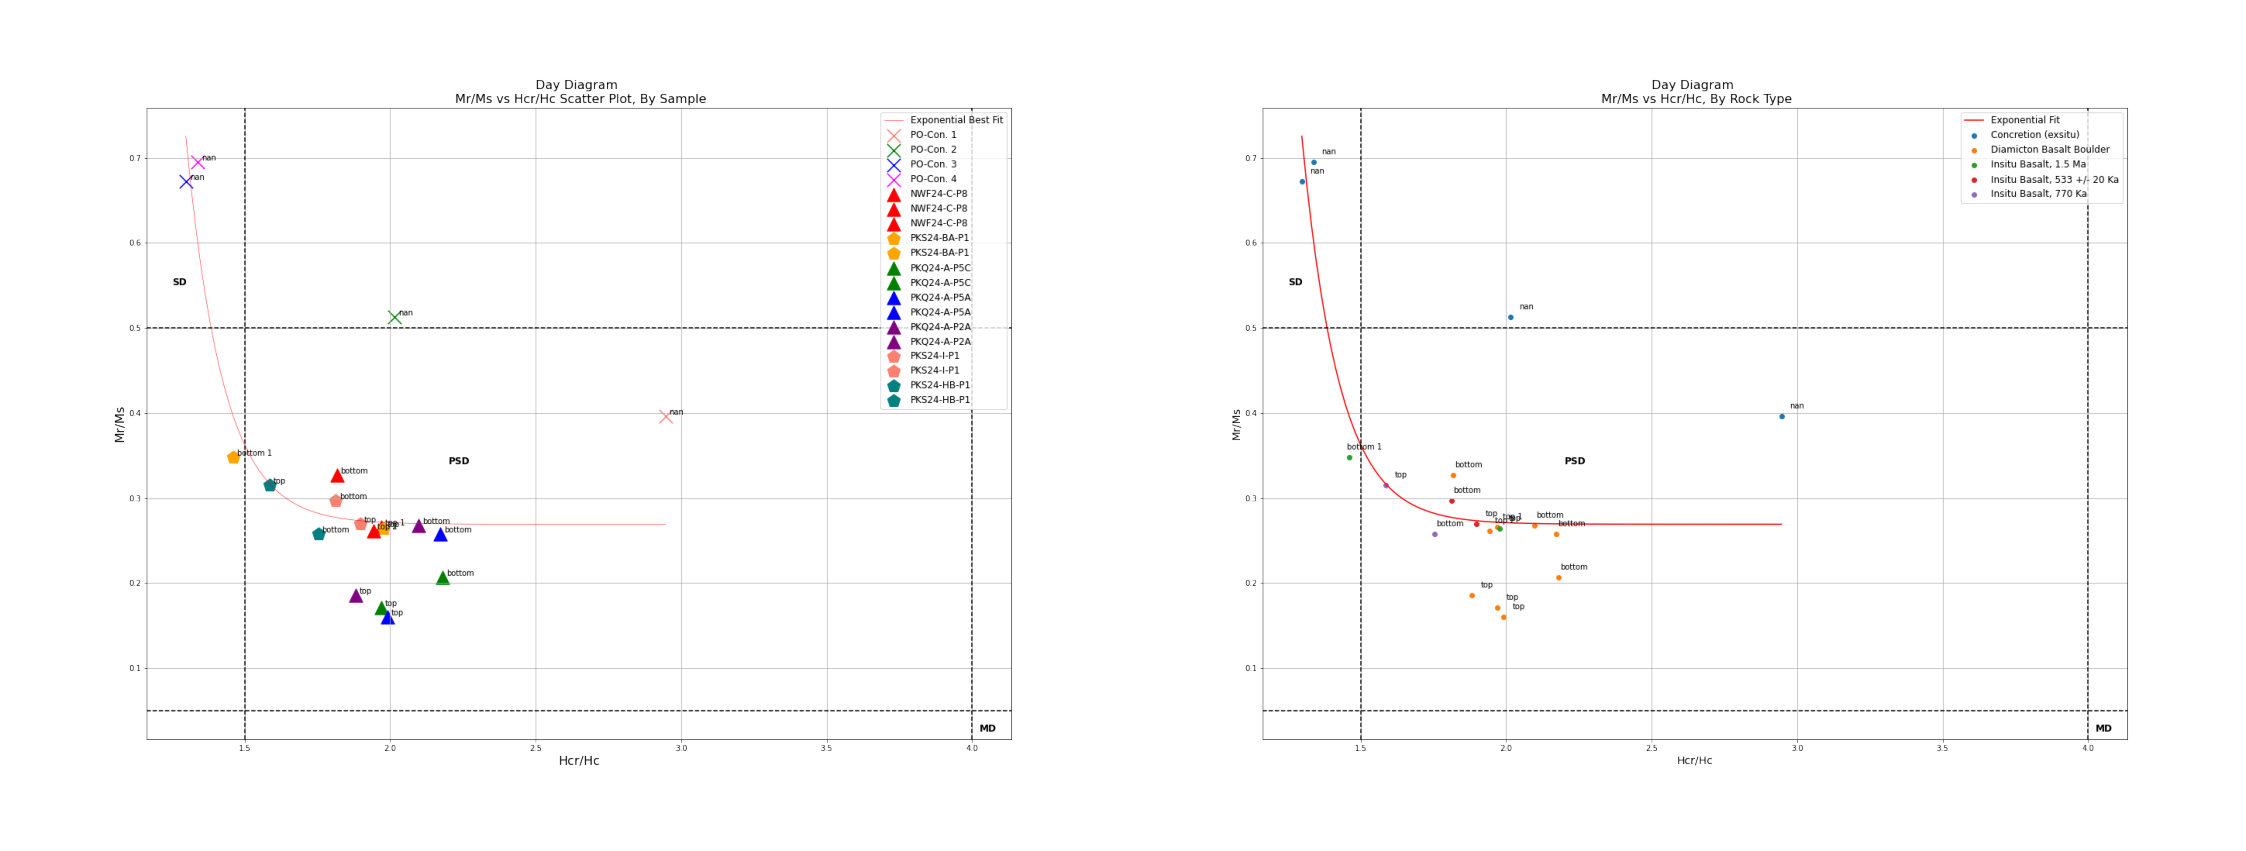

In [112]:
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

day_sample_number = mpimg.imread('./VSM data/Outputs/day_diagram_sample.png')
day_rocktype = mpimg.imread('./VSM data/Outputs/day_diagram_rock_type.png')

fig = plt.figure(figsize=(40., 40.))
grid = ImageGrid(fig, 111,
                nrows_ncols=(1, 2),
                 axes_pad=0)

for ax, im in zip(grid, [day_sample_number,
                        day_rocktype]):
    ax.imshow(im)
    ax.axis("off")


plt.savefig('./VSM Data/Outputs/day_diagram_summary.png', dpi=300)
plt.show()


### Tektites

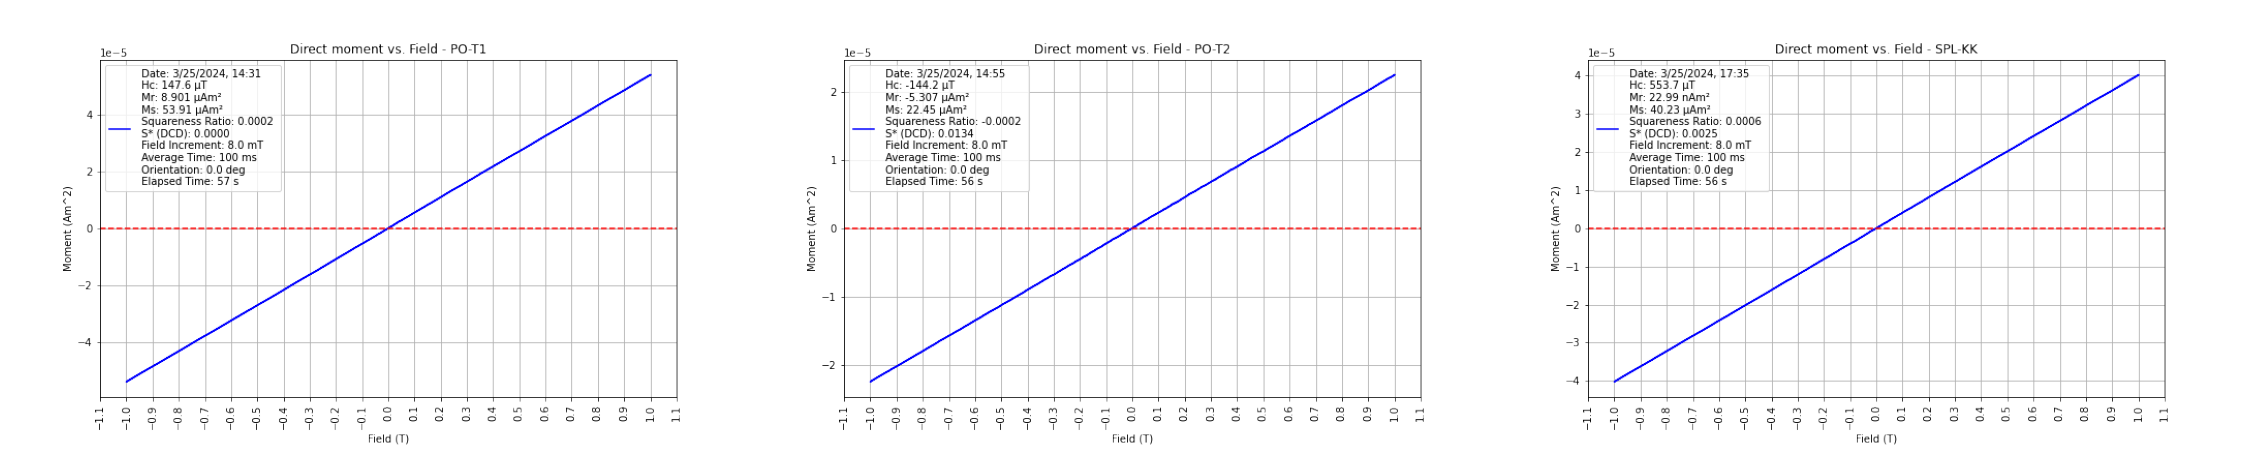

In [113]:
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

PO_T1_hys = mpimg.imread('./VSM data/Outputs/PO-T1-hys.png')
PO_T2_hys = mpimg.imread('./VSM data/Outputs/PO-T2-hys.png')
SPL_KK_hys = mpimg.imread('./VSM data/Outputs/SPL-KK-hys.png')

fig = plt.figure(figsize=(40., 40.))
grid = ImageGrid(fig, 111,
                nrows_ncols=(1, 3),
                 axes_pad=0)

for ax, im in zip(grid, [PO_T1_hys,
                        PO_T2_hys,
                        SPL_KK_hys]):
    ax.imshow(im)
    ax.axis("off")


plt.savefig('./VSM Data/Outputs/tektites_hys_summary.png', dpi=300)
plt.show()


### Concretions

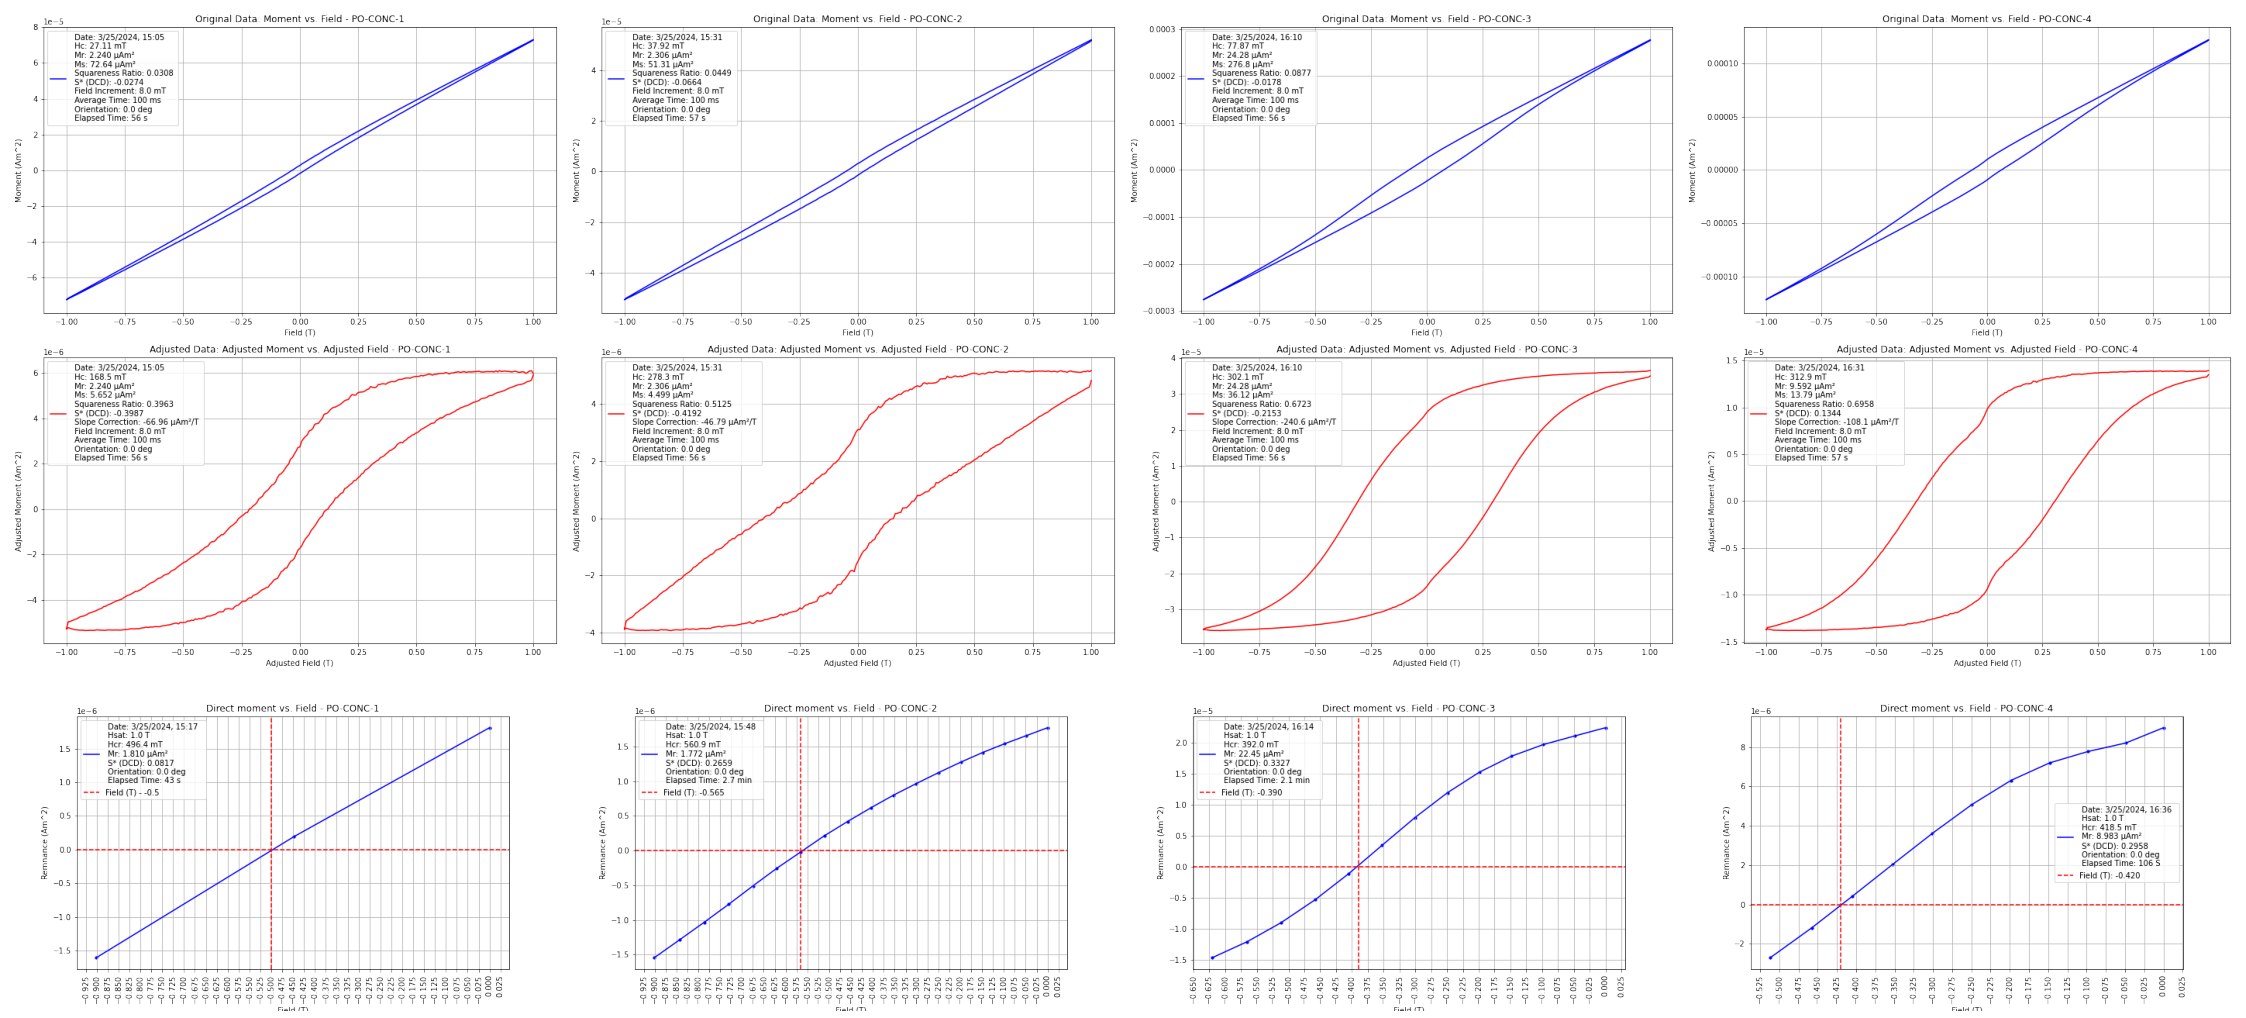

In [114]:
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

PO_CONC_1_hys = mpimg.imread('./VSM data/Outputs/PO-CONC-1-hys.png')
PO_CONC_2_hys = mpimg.imread('./VSM data/Outputs/PO-CONC-2-hys.png')
PO_CONC_3_hys = mpimg.imread('./VSM data/Outputs/PO-CONC-3-hys.png')
PO_CONC_4_hys = mpimg.imread('./VSM data/Outputs/PO-CONC-4-hys.png')

PO_CONC_1_hcr = mpimg.imread('./VSM data/Outputs/PO-CONC-1-hcr.png')
PO_CONC_2_hcr = mpimg.imread('./VSM data/Outputs/PO-CONC-2-hcr.png')
PO_CONC_3_hcr = mpimg.imread('./VSM data/Outputs/PO-CONC-3-hcr.png')
PO_CONC_4_hcr = mpimg.imread('./VSM data/Outputs/PO-CONC-4-hcr.png')


fig = plt.figure(figsize=(40., 40.))
grid = ImageGrid(fig, 111,
                nrows_ncols=(2, 4),
                 axes_pad=0)

for ax, im in zip(grid, [PO_CONC_1_hys,
                        PO_CONC_2_hys,
                        PO_CONC_3_hys,
                        PO_CONC_4_hys,
                        PO_CONC_1_hcr,
                        PO_CONC_2_hcr,
                        PO_CONC_3_hcr,
                        PO_CONC_4_hcr]):
    ax.imshow(im)
    ax.axis("off")

plt.savefig('./VSM Data/Outputs/concretions_hys_hcr_summary.png', dpi=300)
plt.show()


### Basalts

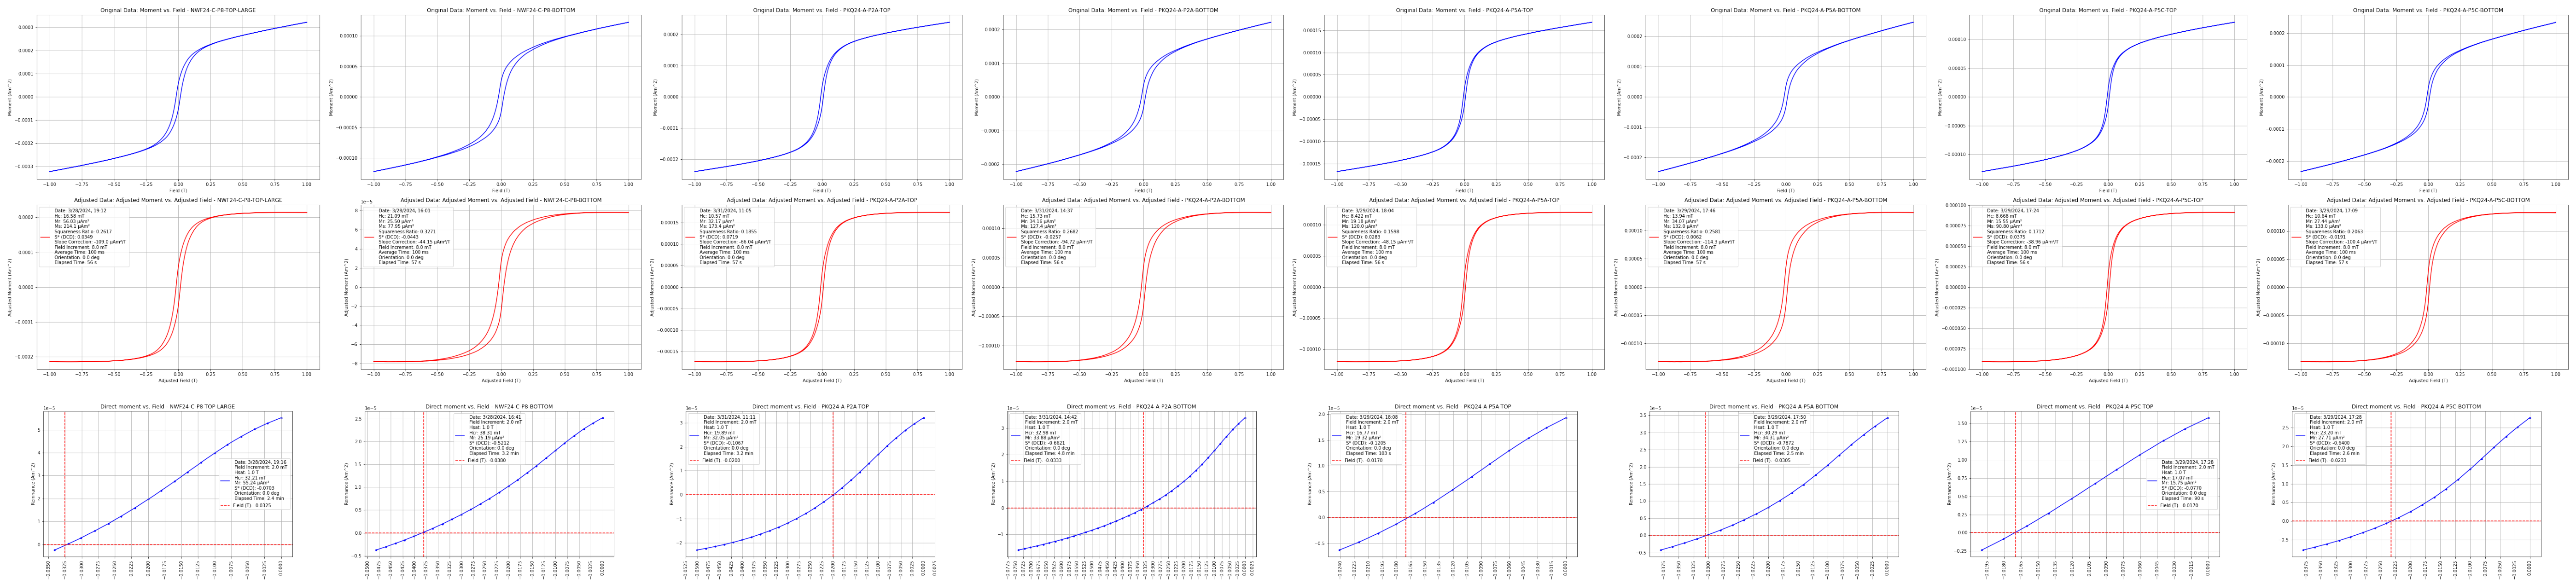

In [162]:
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

#hys
NWF24_C_P8_large_top_hys = mpimg.imread('./VSM data/Outputs/NWF24-C-P8-TOP-LARGE-hys.png')
NWF24_C_P8_small_top_hys = mpimg.imread('./VSM data/Outputs/NWF24-C-P8-TOP-SMALL-hys.png')
NWF24_C_P8_bottom_hys = mpimg.imread('./VSM data/Outputs/NWF24-C-P8-BOTTOM-hys.png')

PKQ24_A_P2A_top_hys = mpimg.imread('./VSM data/Outputs/PKQ24-A-P2A-TOP-hys.png')
PKQ24_A_P2A_bottom_hys = mpimg.imread('./VSM data/Outputs/PKQ24-A-P2A-BOTTOM-hys.png')

PKQ24_A_P5A_top_hys = mpimg.imread('./VSM data/Outputs/PKQ24-A-P5A-TOP-hys.png')
PKQ24_A_P5A_bottom_hys = mpimg.imread('./VSM data/Outputs/PKQ24-A-P5A-BOTTOM-hys.png')

PKQ24_A_P5C_top_hys = mpimg.imread('./VSM data/Outputs/PKQ24-A-P5C-TOP-hys.png')
PKQ24_A_P5C_bottom_hys = mpimg.imread('./VSM data/Outputs/PKQ24-A-P5C-BOTTOM-hys.png')

#hcr
NWF24_C_P8_large_top_hcr = mpimg.imread('./VSM data/Outputs/NWF24-C-P8-TOP-LARGE-hcr.png')
NWF24_C_P8_small_top_hcr = mpimg.imread('./VSM data/Outputs/NWF24-C-P8-TOP-SMALL-hcr.png')
NWF24_C_P8_bottom_hcr = mpimg.imread('./VSM data/Outputs/NWF24-C-P8-BOTTOM-hcr.png')

PKQ24_A_P2A_top_hcr = mpimg.imread('./VSM data/Outputs/PKQ24-A-P2A-TOP-hcr.png')
PKQ24_A_P2A_bottom_hcr = mpimg.imread('./VSM data/Outputs/PKQ24-A-P2A-BOTTOM-hcr.png')

PKQ24_A_P5A_top_hcr = mpimg.imread('./VSM data/Outputs/PKQ24-A-P5A-TOP-hcr.png')
PKQ24_A_P5A_bottom_hcr = mpimg.imread('./VSM data/Outputs/PKQ24-A-P5A-BOTTOM-hcr.png')

PKQ24_A_P5C_top_hcr = mpimg.imread('./VSM data/Outputs/PKQ24-A-P5C-TOP-hcr.png')
PKQ24_A_P5C_bottom_hcr = mpimg.imread('./VSM data/Outputs/PKQ24-A-P5C-BOTTOM-hcr.png')


fig = plt.figure(figsize=(100., 100.))
grid = ImageGrid(fig, 111,
                nrows_ncols=(2, 8),
                 axes_pad=0)

for ax, im in zip(grid, [NWF24_C_P8_large_top_hys,
                        NWF24_C_P8_bottom_hys,
                        PKQ24_A_P2A_top_hys,
                        PKQ24_A_P2A_bottom_hys,
                        PKQ24_A_P5A_top_hys,
                        PKQ24_A_P5A_bottom_hys,
                        PKQ24_A_P5C_top_hys,
                        PKQ24_A_P5C_bottom_hys,
                        NWF24_C_P8_large_top_hcr,
                        NWF24_C_P8_bottom_hcr,
                        PKQ24_A_P2A_top_hcr,
                        PKQ24_A_P2A_bottom_hcr,
                        PKQ24_A_P5A_top_hcr,
                        PKQ24_A_P5A_bottom_hcr,
                        PKQ24_A_P5C_top_hcr,
                        PKQ24_A_P5C_bottom_hcr,]):
    ax.imshow(im)
    ax.axis("off")

plt.savefig('./VSM Data/Outputs/basalts_hys_hcr_summary.png', dpi=300)
plt.show()
